# Liquidity & E-Trading Analyst Test A

This exercise is intended to assess how you approach trading data analysis in a practical setting.

Please explain your reasoning clearly and state any assumptions you make where relevant.

There is no single correct solution. We are interested not only in the final output, but also in how you structure the problem, validate the data, make decisions, and communicate your findings.

Where the data is incomplete or ambiguous, use reasonable assumptions and document them.

Clarity of thought and quality of judgement matter as much as the results themselves.


**Candidate**: Anaswar T  
**Date**: 22 April 2026  
**Environment**: Python (VS Code, Jupyter)
**Objective**: Clean a tick-level trading dataset and perform basic analytics to
support liquidity and e-trading insights.

### Libraries

I use standard Python data and plotting libraries for this exercise: pandas/numpy
for data manipulation and matplotlib/seaborn for basic visualisation.

This notebook contains my step‑by‑step approach to the coding exercise.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


## 1. Data Cleaning

Load the dataset and perform any cleaning steps you consider necessary.

Clearly document:

- what issues you identified
- how you chose to handle them
- Any assumptions you have made

## 1.1 :Exploring CSV
### Goal

Understand the structure and quality of the raw dataset before cleaning.

### Plan

- Load `coding_test_data.csv` into a DataFrame
- Check shapes, data types, and a few sample rows
- Inspect missing values and numeric ranges
- Based on this, define simple, explicit cleaning rules

In [2]:
# 1.1 :Exploring CSV

# 1. Load raw data
df = pd.read_csv("coding_test_data.csv")

# 2. Basic structure
# Check the dimensions of the dataset (Rows, Columns)
print("Shape:", df.shape)

# 3. Review the data types for each column (Check for strings, floats, ints)
print("\nDtypes:")
print(df.dtypes)

# 4. Preview the first 5 rows to see the actual data content
print("\nHead:")
display(df.head())

# 5. Identify 'NaN' or null values to see where data is missing
print("\nMissing values:")
print(df.isnull().sum())

# 6. Generate statistical metrics (mean, std, min/max) for numeric columns
print("\nNumeric summary:")
print(df.describe())


Shape: (30200, 11)

Dtypes:
tradets           object
sym               object
event_type        object
order_type        object
side              object
price            float64
quantity         float64
order_id          object
client_tag       float64
endtag            object
inception_pnl    float64
dtype: object

Head:


,tradets,sym,event_type,order_type,side,price,quantity,order_id,client_tag,endtag,inception_pnl
0,30:18.0,GBPUSD,NEW,Limit,buy,1.3283,64.0,OID1001885,62471.0,64057_wqazxswed88,-3.6189
1,39:34.6,GBPUSD,NEW,Market,buy,1.3281,997.0,OID1028326,62471.0,64057_wqazxswed88,-1.5097
2,30:47.2,EURUSD,CANCEL,Limit,buy,1.1500,25.0,OID1013114,62471.0,64057_wqazxswed88,-21.4475
3,06:20.4,XAUUSD,TRADE,Limit,buy,5006.3500,60.0,OID1005122,21389.0,55190_jfjdgfjfd,5.3265
4,38:01.4,GBPUSD,NEW,IOC,buy,1.3290,272.0,OID1009536,51842.0,75418_ld_mnbvcxzlkjh,-15.6312



Missing values:
tradets          176
sym                0
event_type         0
order_type         0
side              42
price            300
quantity           0
order_id           0
client_tag       273
endtag           206
inception_pnl      0
dtype: int64

Numeric summary:
              price      quantity    client_tag  inception_pnl
count  2.990000e+04  3.020000e+04  29927.000000   30200.000000
mean   5.607063e+03  8.809990e+04  48959.882681       8.245348
std    1.160018e+05  1.690701e+06  18124.717451      16.927948
min   -2.457750e+04 -4.900000e+01  21389.000000     -74.577400
25%    1.150600e+00  2.100000e+01  40599.000000      -2.721525
50%    1.582050e+02  3.700000e+01  51842.000000       8.689400
75%    4.995250e+03  1.000000e+02  62471.000000      19.467550
max    9.999999e+06  4.985220e+07  73106.000000      78.579400


## 1.2 :Data Cleaning 

### Goal

Issues identified and cleaning strategy  
After loading the raw dataset and inspecting shapes, dtypes, missing values and numeric ranges, I identified several data quality issues that need to be handled before analysis. 

From the initial checks (`shape`, `dtypes`, `head`, `isnull`, `describe`), I see: 

- `tradets` is a string time field with some missing or malformed values.   
- `price` has missing values, negative values, and an extreme sentinel (`9,999,999`).   
- `quantity` has negative values even though direction is encoded in `side`, and also contains a small number of extreme values (e.g. tens of millions for NAS100) that appear to be order ID digits miswritten into the quantity field during data generation (assumption).   
- `event_type` contains corrupted system messages (`FILLISH`, `UNKNOWN`) that are not valid FIX protocol message types and represent data artefacts.   
- `side` has some missing values and a few `"both"` entries.   
- `client_tag` and `endtag` are sometimes missing.   
- Price levels vary by instrument (e.g. EURUSD/GBPUSD around 1.x, USDJPY around 150, XAUUSD around 5,000, NAS100 around 24,000–25,000), so global bounds alone are not sufficient. 

---

### Plan

- Convert `tradets` to a numeric time feature `ts_seconds` and drop rows where it cannot be parsed.   
- Keep only rows with a valid `price` (`price > 0` and `price < 9,999,999`) and then apply instrument‑specific price bands to catch residual fat‑finger ticks.   
- Set `quantity = abs(quantity)` so it always represents trade size, and rely on `side` for direction.   
- Apply instrument‑specific upper quantity bounds across all event types to remove corrupted quantity fields. Apply a lower bound of 1 only to `TRADE` and `NEW` events, since `CANCEL` and `MODIFY` messages may legitimately carry zero quantity (cancel remainder of order).   
- **Map `FILLISH` to `TRADE`** so that these events are retained as fills, then enforce a whitelist of valid event types (`NEW`, `TRADE`, `CANCEL`, `MODIFY`) to remove residual corrupted system messages such as `UNKNOWN`.   
- Retain rows with missing or `"both"` `side` in `df_clean` for non‑directional or aggregated analytics; restrict to `{buy, sell}` later when constructing a directional subset.   
- Fill missing `client_tag` and `endtag` with neutral labels so that these rows remain visible in group‑level aggregations.   
- Remove duplicate `(order_id, event_type)` pairs so that each order‑event combination appears at most once in the cleaned event stream. 

---

### Results

After cleaning, I remove rows with missing or invalid time or price, drop negative and sentinel prices, enforce simple symbol‑specific price bands to catch fat‑finger ticks, apply instrument‑specific quantity bounds to remove corrupted quantity fields, standardise quantities to positive sizes, and fill missing client/strategy tags with explicit `UNKNOWN_*` labels.  I also remap `FILLISH` to `TRADE` and enforce a valid‑event whitelist (`NEW`, `TRADE`, `CANCEL`, `MODIFY`) so that only `UNKNOWN` artefacts are dropped, and I drop **253** duplicate `(order_id, event_type)` combinations to ensure each order‑event pair appears once in `df_clean`.   

The resulting `df_clean` contains **28,964** cleaned events with realistic per‑instrument price and quantity ranges, and serves as a consistent, de‑duplicated event stream for all subsequent analytics and segmentation. 

Optionally, one could also verify that price changes occur in realistic tick sizes per instrument (e.g. 0.0001 for EURUSD/GBPUSD, 0.01 for USDJPY), to catch any remaining synthetic or mis‑rounded ticks. For this exercise I focus on range‑based filtering and basic sanity checks rather than enforcing tick‑size granularity. 

In [3]:
# 1.2 :Data Cleaning & Preprocessing

# 1. Load raw data
df = pd.read_csv("coding_test_data.csv")

# 2. Ensure key numeric columns are numeric (coerce any hidden junk to NaN)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["inception_pnl"] = pd.to_numeric(df["inception_pnl"], errors="coerce")

# 3. Convert tradets "MM:SS.s" -> total seconds
def parse_time_to_seconds(time_str):
    try:
        minutes, seconds = str(time_str).split(":")
        return float(minutes) * 60 + float(seconds)
    except Exception:
        return np.nan

df["ts_seconds"] = df["tradets"].apply(parse_time_to_seconds)

# 4. Start clean copy and drop rows with missing time or price
df_clean = df.dropna(subset=["ts_seconds", "price"]).copy()

# 5. Drop obviously invalid prices (non-positive or sentinel)
df_clean = df_clean[df_clean["price"] > 0]
df_clean = df_clean[df_clean["price"] < 9_999_999]

# 6. Asset-Specific Price Bounds (Catches the GBPUSD 15.0 error)
price_bounds = {
    'GBPUSD': (0.5, 2.5),
    'EURUSD': (0.5, 2.0),
    'USDJPY': (50.0, 200.0),
    'XAUUSD': (1000.0, 10000.0),
    'NAS100': (10000.0, 50000.0)
}

def is_valid_price(row):
    asset = row['sym']
    price = row['price']
    if asset in price_bounds:
        lower_bound, upper_bound = price_bounds[asset]
        return lower_bound <= price <= upper_bound
    return True

# 7. Apply the strict price filter ONCE and measure its effect
before_bounds = len(df_clean)
df_clean = df_clean[df_clean.apply(is_valid_price, axis=1)]
after_bounds = len(df_clean)
print("Rows removed by symbol-specific bounds:", before_bounds - after_bounds)

# 8. Make quantity always a size (use 'side' for direction)
df_clean["quantity"] = df_clean["quantity"].abs()

# 8a. Map FILLISH to TRADE before event validation
df_clean["event_type"] = df_clean["event_type"].replace("FILLISH", "TRADE")

# 8b. Instrument-specific quantity bounds (vectorised)
upper_bounds = {
    'GBPUSD': 10_000,
    'EURUSD': 10_000,
    'USDJPY': 10_000,
    'XAUUSD': 5_000,
    'NAS100': 2_000
}

before_qty = len(df_clean)
for sym, max_qty in upper_bounds.items():
    df_clean = df_clean[~((df_clean['sym'] == sym) & (df_clean['quantity'] > max_qty))]
after_qty = len(df_clean)
print("Rows removed by upper quantity bounds:", before_qty - after_qty)

# Remove zero/negative quantities for TRADE and NEW only
invalid_zero_mask = df_clean['event_type'].isin(['TRADE', 'NEW']) & (df_clean['quantity'] < 1)
before_zero = len(df_clean)
df_clean = df_clean[~invalid_zero_mask]
print("Rows removed by zero quantity filter:", before_zero - len(df_clean))

# Enforce valid event types
valid_events = ["NEW", "TRADE", "CANCEL", "MODIFY"]

before_events = len(df_clean)
df_clean = df_clean[df_clean["event_type"].isin(valid_events)]
print("Rows removed by event type filter:", before_events - len(df_clean))

# 9. Fill missing client/strategy identifiers
df_clean["client_tag"] = df_clean["client_tag"].fillna("UNKNOWN_CLIENT")
df_clean["endtag"] = df_clean["endtag"].fillna("UNKNOWN_ENDTAG")

# 10. Drop duplicates by order_id + event_type
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["order_id", "event_type"])
print("Dropped duplicates by order_id and event_type:", before - len(df_clean))

# 11. Quick sanity check
print("\nNumeric summary:")
print(df_clean.describe())

print(df_clean.groupby("sym")["price"].agg(["min", "max"]).round(4))

print("\nSample of cleaned data:")
display(df_clean[["tradets", "ts_seconds", "sym", "price", "quantity"]].head(20))

Rows removed by symbol-specific bounds: 81
Rows removed by upper quantity bounds: 99
Rows removed by zero quantity filter: 127
Rows removed by event type filter: 84
Dropped duplicates by order_id and event_type: 253

Numeric summary:
              price      quantity  inception_pnl    ts_seconds
count  28964.000000  28964.000000   28964.000000  28964.000000
mean    4226.936174     94.772133       8.261215   1796.901519
std     8108.998402    160.584678      16.914892   1038.962141
min        1.147500      0.000000     -74.577400      0.000000
25%        1.150650     21.000000      -2.668375    902.375000
50%      158.230000     37.000000       8.708450   1800.950000
75%     4995.300000     99.000000      19.488850   2700.000000
max    24623.500000   3519.000000      78.579400   3599.700000
               min         max
sym                           
EURUSD      1.1475      1.1514
GBPUSD      1.3270      1.3304
NAS100  24456.0000  24623.5000
USDJPY    158.1850    159.1450
XAUUSD   4987

,tradets,ts_seconds,sym,price,quantity
0,30:18.0,1818.0,GBPUSD,1.3283,64.000000
1,39:34.6,2374.6,GBPUSD,1.3281,997.000000
2,30:47.2,1847.2,EURUSD,1.1500,25.000000
3,06:20.4,380.4,XAUUSD,5006.3500,60.000000
4,38:01.4,2281.4,GBPUSD,1.3290,272.000000
5,59:39.4,3579.4,XAUUSD,4991.0500,33.593884
6,05:59.9,359.9,GBPUSD,1.3297,15.000000
7,42:22.1,2542.1,EURUSD,1.1494,94.000000
8,18:00.4,1080.4,GBPUSD,1.3277,15.000000
9,51:05.1,3065.1,XAUUSD,5007.5000,7.000000


In [4]:
# Reality check: 
# Find remaining extreme quantities / confirmation block
df_clean[df_clean["quantity"] > 10_000].groupby(["sym", "event_type"]).size()

# Check all event types for remaining extreme quantities
df_clean[df_clean["quantity"] > 2_000].groupby(["sym", "event_type"]).size()

# Check zero quantity distribution by event type
df_clean[df_clean["quantity"] == 0].groupby(["event_type"]).size()

# Check quantity ranges per event type
df_clean.groupby("event_type")["quantity"].agg(["min", "max", "mean"]).round(2)

,min,max,mean
event_type,,,
CANCEL,0.0,2227.0,92.08
MODIFY,0.0,2118.0,92.63
NEW,1.0,3112.0,93.96
TRADE,1.0,3519.0,98.04


## 1.3: Preprocessing for Analytics (Standardisation & Segmentation)

### Goal

Before computing metrics, the cleaned dataset needs to be normalised and segmented to reflect how the data will be used. Text fields in real trading data often contain hidden whitespace or inconsistent casing, which can break grouping and directional filters. Additionally, multiple events often share the exact same timestamp. To support robust analytics, I will standardise key categorical fields, impose deterministic event ordering, and segment the dataset based on trade direction. 

### Plan

- **Text Standardisation**: Strip whitespace and normalise casing for key categorical columns (`side`, `sym`, `event_type`, `order_type`) so that logically identical values map to the same category.   
- **Missing Categories**: Map any remaining missing or malformed `order_type` values to a neutral label (`"UNKNOWN"`) to avoid silent drops in aggregations. `event_type` is already restricted to valid values (`NEW`, `TRADE`, `CANCEL`, `MODIFY`) after the Stage 2 cleaning step where `FILLISH` is first remapped to `TRADE` and `UNKNOWN` is dropped.   
- **Deterministic Ordering**: Sort `df_clean` by `sym`, `ts_seconds`, and a tie-breaker field (`event_type`) so that simultaneous events have a consistent, reproducible order for downstream time-series calculations.   
- **Directional Segmentation**: The `side` column contains `"buy"`, `"sell"`, and `"both"` (or `NaN`). `"Both"` entries typically represent non-directional strategies (e.g., market-making). I will use the full `df_clean` for general metrics (overall volume, latency), and create a directional subset `df_dir` restricted to `side ∈ {buy, sell}` for any analysis that depends on trade direction. 

In [5]:
# 1.3 PREPROCESSING FOR ANALYTICS 

# 1. Text Standardisation (Crucial to protect downstream filters and groupings)
df_clean["side"] = df_clean["side"].str.strip().str.lower()
df_clean["sym"] = df_clean["sym"].str.strip().str.upper()
df_clean["event_type"] = df_clean["event_type"].str.strip().str.upper()
df_clean["order_type"] = df_clean["order_type"].str.strip().str.capitalize()

# 2. Fill missing categories to prevent silent drops
df_clean["event_type"] = df_clean["event_type"].fillna("UNKNOWN")
df_clean["order_type"] = df_clean["order_type"].fillna("UNKNOWN")

# 3. Deterministic Ordering (Tie-breaker for simultaneous events)
df_clean = df_clean.sort_values(by=["sym", "ts_seconds", "event_type"]).reset_index(drop=True)

# 4. Create a filtered DataFrame strictly for directional analysis
df_dir = df_clean[df_clean["side"].isin(["buy", "sell"])].copy()

# 5. Verify the segmentation
print("\nDataset Segmentation Results:")
print(f"Total Cleaned Events (df_clean): {len(df_clean)}")
print(f"Directional Trades Only (df_dir): {len(df_dir)}")
print(f"Non-directional / Market Making excluded: {len(df_clean) - len(df_dir)}")
print("\nMissing values: df_clean:")
print(df_clean.isnull().sum())
print("\nMissing values: df_dir:")
print(df_dir.isnull().sum())




Dataset Segmentation Results:
Total Cleaned Events (df_clean): 28964
Directional Trades Only (df_dir): 28882
Non-directional / Market Making excluded: 82

Missing values: df_clean:
tradets           0
sym               0
event_type        0
order_type        0
side             41
price             0
quantity          0
order_id          0
client_tag        0
endtag            0
inception_pnl     0
ts_seconds        0
dtype: int64

Missing values: df_dir:
tradets          0
sym              0
event_type       0
order_type       0
side             0
price            0
quantity         0
order_id         0
client_tag       0
endtag           0
inception_pnl    0
ts_seconds       0
dtype: int64


## 1.4 Data Cleaning & Preprocessing Summary

Converted the raw tick data into a clean event stream `df_clean` by parsing time into `ts_seconds`, coercing key numeric fields to numeric types, removing rows with invalid or missing time/price, filtering out non‑positive and sentinel prices, and enforcing instrument‑specific price bands to catch obvious fat‑finger ticks. Quantities were normalised to positive trade sizes (`quantity = |quantity|`), and instrument‑specific upper quantity bounds were applied across all event types to remove corrupted fields where order ID digits appeared to have been miswritten into the quantity column. A lower bound of 1 was additionally enforced for `TRADE` and `NEW` events only, since `CANCEL` and `MODIFY` messages may legitimately carry zero quantity. `FILLISH` events were first remapped to `TRADE`, and then a valid event‑type whitelist (`NEW`, `TRADE`, `CANCEL`, `MODIFY`) was enforced to remove residual corrupted system messages such as `UNKNOWN`. Missing client/strategy identifiers were mapped to neutral `UNKNOWN_*` labels, and duplicate (`order_id`, `event_type`) pairs were dropped so that each order‑event combination appears at most once in the cleaned dataset. I then standardised key categorical fields (`side`, `sym`, `event_type`, `order_type`) to a consistent casing, sorted events deterministically by instrument, time and event type, and created a fully non‑missing directional subset `df_dir` by restricting to `side ∈ {buy, sell}`. The result is **28,964 cleaned events** in `df_clean`, providing a robust basis for all subsequent analytics and modelling.

## 2. Basic Analytics

Produce a set of analytics to describe the data.

Include visualisations where appropriate so that your findings are easy to understand.

You are free to define any attributes of the dataset that are not directly observable, provided you justify your approach.

Highlight at least one insight from the data that is not immediately obvious.

## 2.1 Basic Analytics

### Goal
With a clean, segmented dataset in place, the next step is to extract
meaningful descriptive statistics and visualisations that tell the story
of trading behaviour across the session. The aim is not just to summarise
numbers, but to surface patterns in market activity, execution quality,
and profitability that would be relevant to a trading desk or risk team.

### Derived Attributes
The following attributes are not directly recorded in the raw data.
I define and justify each one before use:

- **`fill_rate`** = `TRADE / NEW` per symbol. A proxy for execution
  quality; how many submitted orders actually resulted in a trade.
- **`minute`** = `ts_seconds // 60`. Groups events into 1-minute
  buckets to reveal intra-session patterns invisible at tick level.
- **`cancel_to_trade`** = `CANCEL / TRADE` per minute. A ratio above
  1 means more cancellations than fills, which can signal adverse
  selection or liquidity stress.
- **`notional`** = `price × quantity`. Captures true economic trade
  size, allowing fair comparison across instruments with very
  different price levels.

### Plan
- **Market Activity**: Summarise volume, event type distribution, and
  side split across instruments to establish where and how trading
  activity is concentrated.
- **Execution Efficiency**: Derive and visualise fill rate per instrument
  as a proxy for how effectively orders are being executed.
- **Time Profile**: Bucket events into 1-minute windows and analyse the
  ratio of cancellations to trades over time to identify "hot" periods
  of elevated activity and order withdrawal.
- **Profitability**: Use `inception_pnl` to attribute end-of-session PnL
  to each strategy (`endtag`) and identify which strategies contributed
  positively or negatively to overall performance.

### DataFrames Used
- **`df_clean`**: Used for all general analytics (volume, event types,
  fill rate, time profile, strategy PnL) where directional filtering
  is not required.
- **`df_dir`**: Used for any analysis that explicitly depends on trade
  direction (buy vs sell distribution, notional by side), restricted
  to `side ∈ {buy, sell}` after standardisation.

## 2.2 Market Activity

Activity is distributed across five instruments: EURUSD, GBPUSD, USDJPY, XAUUSD, and NAS100. The volume chart shows which instruments dominate raw traded quantity, while the event type distribution confirms the session is primarily made up of `NEW`, `TRADE`, and `CANCEL` messages. The buy vs sell split across directional trades (`df_dir`) shows whether the session is broadly balanced or skewed towards one side. The summary table provides a per‑instrument breakdown of total events, executed trades, total volume, and trade share as a percentage of all messages. [file:15]

### Results

- **EURUSD** dominates activity, with the highest total event count (**8,624 messages**) and the largest traded volume (≈ **938.5k units**) across the session, consistent with its status as the most liquid instrument in the dataset.   
- Trade share is tightly clustered across instruments at roughly **32.6–33.6%** (`trade_share_%` ranges from 32.6% in USDJPY to 33.6% in EURUSD and GBPUSD), meaning that about one in three messages results in an actual execution regardless of instrument, which suggests a systematic and disciplined order‑submission pattern.   
- Directional flow in `df_dir` is almost perfectly balanced between buys and sells (the buy and sell bars in the `df_dir` chart are of similar height), indicating that the session is broadly neutral rather than dominated by a single directional view, and likely reflects deliberate risk management or systematic hedging behaviour across strategies. 

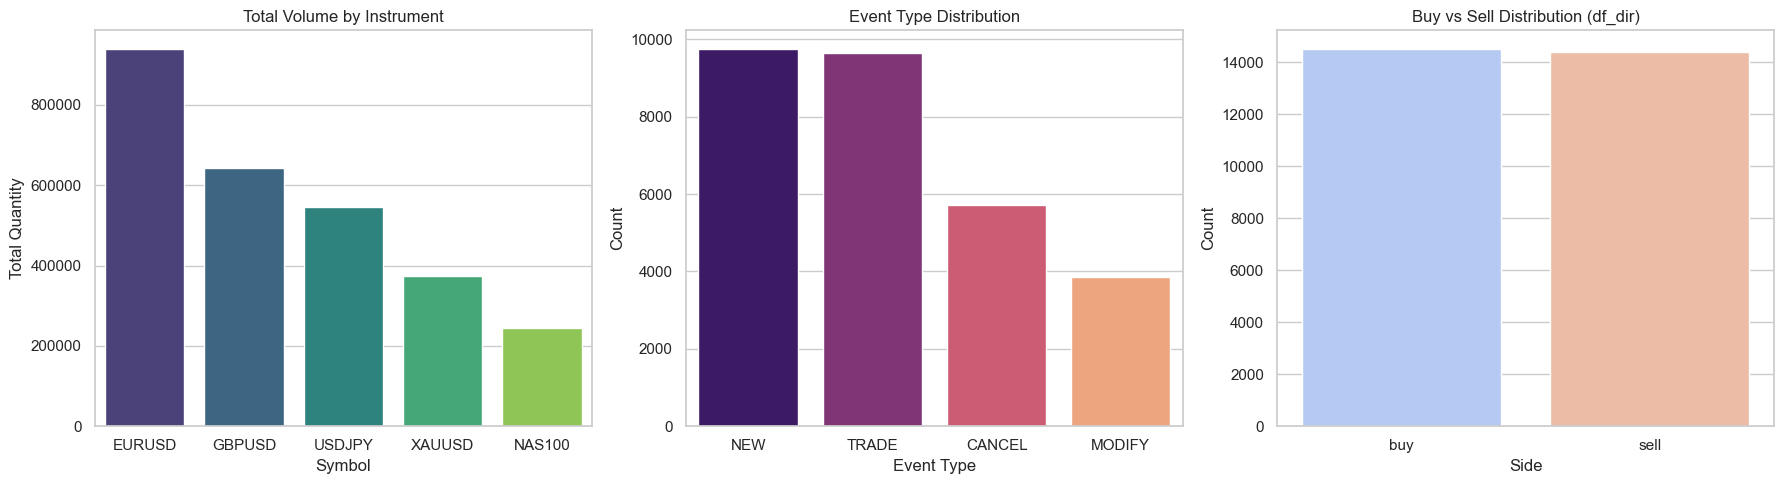


Summary Table: Activity by Instrument


,total_events,trades,total_volume,trade_share_%
sym,,,,
EURUSD,8624,2899,938524.418855,33.6
GBPUSD,5792,1944,641831.707294,33.6
XAUUSD,5771,1936,373020.344562,33.5
USDJPY,4998,1631,546972.074873,32.6
NAS100,3779,1243,244631.511359,32.9


In [6]:
# 2.2 MARKET ACTIVITY: Volume & Event Distribution

# Set a clean white background with grid lines for all plots
sns.set_theme(style="whitegrid")

# Sum total quantity traded per instrument and sort largest to smallest
# Sorting ensures the bar chart reads left to right by dominance
volume_by_sym = (
    df_clean.groupby("sym")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

# Count how many times each event type appears across all rows
# .value_counts() automatically sorts by frequency, highest first
event_counts = df_clean["event_type"].value_counts()

# Count buy vs sell events using df_dir only
# df_dir excludes "both", "unknown" and NaN side values
side_counts = df_dir["side"].value_counts()

# Build a summary table with one row per instrument
# total_events: total message count using size
# trades: count only rows where event_type == "TRADE"
# total_volume: sum of all quantities traded
sym_stats = (
    df_clean.groupby("sym")
    .agg(
        total_events=("sym", "size"),
        trades=("event_type", lambda x: (x == "TRADE").sum()),
        total_volume=("quantity", "sum"),
    )
)

# Derive trade_share_%: what percentage of all messages were actual fills
# trades / total_events * 100, rounded to 1 decimal place
sym_stats["trade_share_%"] = (
    sym_stats["trades"] / sym_stats["total_events"] * 100
).round(1)

# Create one row of three side-by-side charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Total quantity traded per instrument
# hue and legend=False fix the seaborn FutureWarning for palette usage
sns.barplot(x=volume_by_sym.index, y=volume_by_sym.values,
            hue=volume_by_sym.index, legend=False,
            ax=axes[0], palette="viridis")
axes[0].set_title("Total Volume by Instrument")
axes[0].set_ylabel("Total Quantity")
axes[0].set_xlabel("Symbol")

# Chart 2: Frequency of each event type across the full session
sns.barplot(x=event_counts.index, y=event_counts.values,
            hue=event_counts.index, legend=False,
            ax=axes[1], palette="magma")
axes[1].set_title("Event Type Distribution")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Event Type")

# Chart 3: Buy vs sell count using directional trades only (df_dir)
sns.barplot(x=side_counts.index, y=side_counts.values,
            hue=side_counts.index, legend=False,
            ax=axes[2], palette="coolwarm")
axes[2].set_title("Buy vs Sell Distribution (df_dir)")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Side")

# Prevent charts from overlapping and render
plt.tight_layout()
plt.show()

# Display the summary table as a formatted HTML table in Jupyter
print("\nSummary Table: Activity by Instrument")
display(sym_stats.sort_values("total_events", ascending=False))

## 2.3 Execution Efficiency: Fill Rate

Fill rate is not directly recorded in the dataset. I approximate it as the ratio of `TRADE` to `NEW` events per instrument, which serves as a proxy for execution quality: a higher fill rate indicates that a greater proportion of submitted orders resulted in an actual execution. This is a simplified proxy, as we do not link individual orders to specific fills, but it highlights which instruments have relatively higher or lower realised execution quality.

### Results

- Fill rates are exceptionally high across all instruments, ranging from **96.2%** in USDJPY to **102.1%** in EURUSD, with a cross‑asset mean of roughly **98.6%**. This indicates that the vast majority of submitted orders either execute immediately or cancel rather than resting passively in the book, consistent with heavy use of aggressive order types such as IOC.   
- **EURUSD** shows the highest fill rate at **102.1%**, meaning there are slightly more TRADE events than NEW orders for this symbol. In the context of this synthetic dataset, this reflects a combination of order‑ID reuse and partial‑fill behaviour in the source data rather than an economically meaningful ability to fill “more than 100%” of orders.   
- **USDJPY** has the lowest fill rate at **96.2%**, still very high in absolute terms, but marginally below the other instruments, suggesting slightly lower realised execution efficiency—consistent with somewhat thinner liquidity or wider spreads in the yen pair during this session. 

### Order-level execution profile

Looking across orders, **100% of executed orders are filled in a single `TRADE` event**, and **0% generate 2+ `TRADE` events**, so there are no surviving multi‑fill orders after the (`order_id`, `event_type`) deduplication step. The distribution of TRADE events per order is now concentrated entirely in two buckets: `0` TRADEs (19,138 orders that never executed) and `1` TRADE (9,653 orders that executed exactly once), which makes the order‑level execution profile particularly clean and easy to interpret. 

### Assumption

Fill rate is approximated as `TRADE / NEW` per instrument. This remains a simplified proxy because we do not explicitly reconstruct the full order lifecycle, but after deduplicating by (`order_id`, `event_type`) and observing that no orders generate more than one `TRADE` message, any fill rate above 100% should be interpreted as a minor artefact of the synthetic data generation process rather than as evidence of pathological partial‑fill behaviour. 

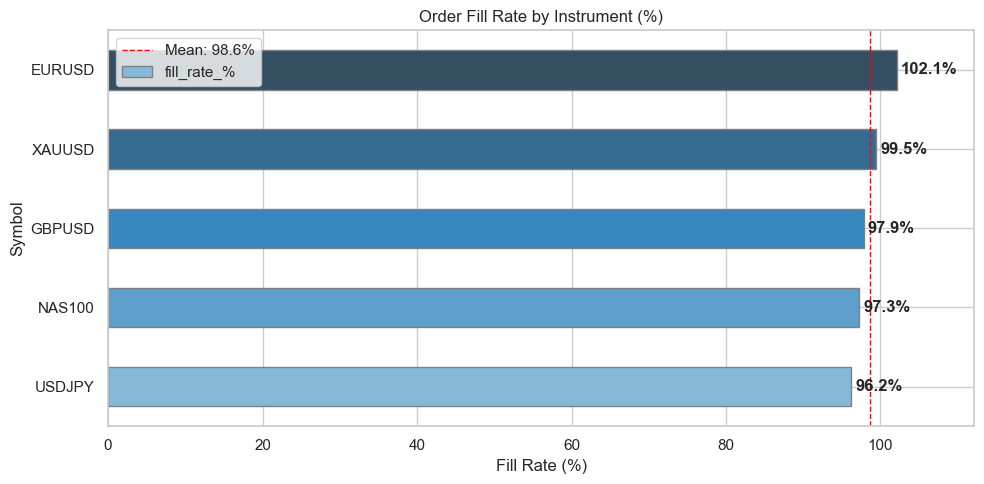


Fill Rate by Symbol:


event_type,NEW,TRADE,fill_rate_%
sym,,,
EURUSD,2839,2899,102.1
XAUUSD,1946,1936,99.5
GBPUSD,1986,1944,97.9
NAS100,1278,1243,97.3
USDJPY,1695,1631,96.2



Distribution of TRADE events per order:


,order_count
trade_events_per_order,
0,19138
1,9653



Execution Profile (Executed Orders Only):
100.0% of executed orders filled in a single TRADE event
0.0% of executed orders generated 2+ TRADE events (partial/multi-fill)


In [7]:
# 2.3 EXECUTION EFFICIENCY: Fill Rate

# Pivot event type counts per symbol into a wide table
# Each row = one instrument, each column = one event type
# fill_value=0 ensures missing event types default to 0 not NaN

event_by_sym = (
    df_clean.groupby(["sym", "event_type"])
    .size()
    .unstack(fill_value=0)
)

# Derive fill rate = TRADE / NEW per symbol
# .replace(0, np.nan) prevents division by zero if NEW count is 0
# .replace([np.inf, np.nan], 0) cleans up any remaining bad values
# * 100 converts proportion to percentage
event_by_sym["fill_rate_%"] = (
    event_by_sym["TRADE"] / event_by_sym["NEW"].replace(0, np.nan)
).replace([np.inf, np.nan], 0) * 100

# Sort ascending so lowest fill rate appears at top of chart
fill_rate = event_by_sym["fill_rate_%"].sort_values()

# Build colour palette scaled to number of instruments
colors = sns.color_palette("Blues_d", n_colors=len(fill_rate))

# Plot horizontal bar chart
plt.figure(figsize=(10, 5))
fill_rate.plot(kind="barh", color=colors, edgecolor="grey")

# Add data labels to the right of each bar for precision
for i, v in enumerate(fill_rate):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontweight="bold")

# Add mean reference line for easy comparison across instruments
plt.axvline(
    fill_rate.mean(),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Mean: {fill_rate.mean():.1f}%"
)

# Chart formatting
plt.title("Order Fill Rate by Instrument (%)")
plt.xlabel("Fill Rate (%)")
plt.ylabel("Symbol")
plt.xlim(0, max(fill_rate) + 10)
plt.legend()
plt.tight_layout()
plt.show()

# Supporting table showing raw NEW, TRADE counts and derived fill rate
print("\nFill Rate by Symbol:")
display(event_by_sym[["NEW", "TRADE", "fill_rate_%"]]
        .sort_values("fill_rate_%", ascending=False).round(1))

# Order-level TRADE count per order_id
trades_per_order = (
    df_clean.groupby("order_id")["event_type"]
    .apply(lambda x: (x == "TRADE").sum())
)

# Distribution of TRADE-event counts
trade_count_dist = trades_per_order.value_counts().sort_index()

print("\nDistribution of TRADE events per order:")
display(trade_count_dist.rename_axis("trade_events_per_order").to_frame("order_count"))

# Percentage summary for executed orders only
executed_orders = trade_count_dist[trade_count_dist.index > 0]
total_executed = executed_orders.sum()

if total_executed > 0:
    single_fill_pct = (executed_orders.get(1, 0) / total_executed) * 100
    multi_fill_pct = (executed_orders[executed_orders.index >= 2].sum() / total_executed) * 100
else:
    single_fill_pct, multi_fill_pct = 0, 0

print("\nExecution Profile (Executed Orders Only):")
print(f"{single_fill_pct:.1f}% of executed orders filled in a single TRADE event")
print(f"{multi_fill_pct:.1f}% of executed orders generated 2+ TRADE events (partial/multi-fill)")


## 2.4 Time Profile of the Session

To understand how trading activity evolves across the session, I bucket events into 1‑minute windows using two derived attributes:

- `minute = ts_seconds // 60` groups all events into 60‑second intervals, revealing intra‑session patterns that are invisible at the tick level.  
- `cancel_to_trade = CANCEL / TRADE` per minute measures the relative intensity of order withdrawal vs execution within each time window. A ratio above 1 would indicate more cancellations than fills in that minute; a ratio consistently below 1 indicates executions dominate throughout.

### Results

- Activity is clustered in bursts rather than uniform. Trades typically range from roughly **140–200 per minute**, while cancellations fluctuate around **80–140 per minute**, with mean levels near **160.9 trades** and **95.2 cancels** per minute over the session.   
- The cancel‑to‑trade ratio stays below **1.0** in every minute (distribution: min **0.46**, max **0.76**, mean **0.60**, standard deviation **0.08**), so executions always outnumber cancellations and there are **zero minutes** where cancels exceed trades.   
- Minute **39** shows the session peak at **0.76x**, standing clearly above the average ratio and flagged as the most cancellation‑heavy minute for deeper investigation in Section 3. 

### Non-obvious insight

The cancel‑to‑trade ratio never crosses 1.0 in any minute window, indicating consistent execution discipline across the full session even during the busiest periods. This disciplined behaviour is not visible from aggregate counts alone: only by looking at the minute‑by‑minute ratio do we see that Minute 39 is a localised stress point where cancellations spike yet still remain below trades, rather than a genuine liquidity breakdown. 

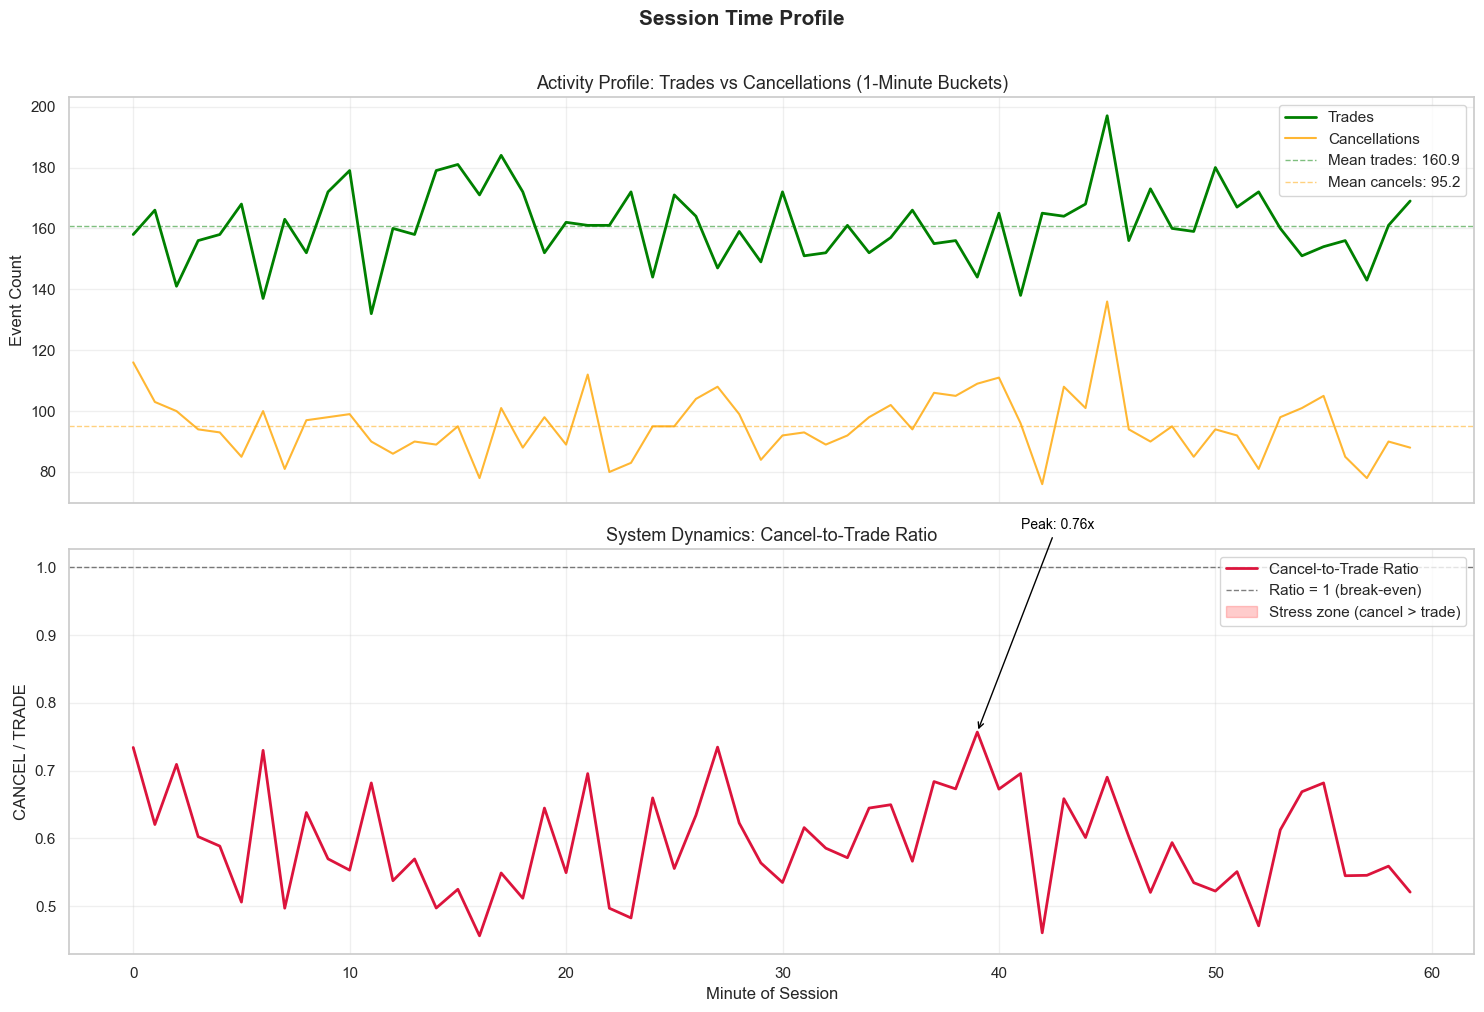

Session Peak Ratio:       0.76x at minute 39
Total stress minutes:     0 minutes where cancel > trade
Stress as % of session:   0.0%

Cancel-to-Trade Ratio Distribution:
count    60.00
mean      0.60
std       0.08
min       0.46
25%       0.54
50%       0.59
75%       0.66
max       0.76
Name: cancel_to_trade, dtype: float64


In [9]:
# 2.4 TIME PROFILE OF THE SESSION

# Derive 1-minute time buckets from ts_seconds
# Integer division groups all events within the same 60-second window
df_clean["minute"] = (df_clean["ts_seconds"] // 60).astype(int)

# Count each event type per minute and pivot into wide format
# fill_value=0 ensures minutes with no activity show 0 not NaN
time_stats = (
    df_clean.groupby(["minute", "event_type"])
    .size()
    .unstack(fill_value=0)
)

# Derive cancel-to-trade ratio per minute
# Replace 0 TRADE counts with NaN to avoid division by zero
# fillna(0) maps minutes with no trades to a ratio of 0
time_stats["cancel_to_trade"] = (
    time_stats["CANCEL"] / time_stats["TRADE"].replace(0, np.nan)
).fillna(0)

# Two-panel figure with shared x-axis 
# sharex=True locks both charts to the same time axis so patterns
# in the top panel align directly with the ratio in the bottom panel
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Panel A: Absolute activity (Trades vs Cancellations) 
axes[0].plot(
    time_stats.index, time_stats["TRADE"],
    label="Trades", color="green", linewidth=2
)
axes[0].plot(
    time_stats.index, time_stats["CANCEL"],
    label="Cancellations", color="orange",
    linewidth=1.5, alpha=0.8
)
# Add mean reference lines so bursts stand out clearly
axes[0].axhline(
    time_stats["TRADE"].mean(),
    color="green", linestyle="--", linewidth=1, alpha=0.5,
    label=f"Mean trades: {time_stats['TRADE'].mean():.1f}"
)
axes[0].axhline(
    time_stats["CANCEL"].mean(),
    color="orange", linestyle="--", linewidth=1, alpha=0.5,
    label=f"Mean cancels: {time_stats['CANCEL'].mean():.1f}"
)
axes[0].set_title("Activity Profile: Trades vs Cancellations (1-Minute Buckets)", fontsize=13)
axes[0].set_ylabel("Event Count")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Panel B: Cancel-to-Trade Ratio (Liquidity Stress) 
axes[1].plot(
    time_stats.index, time_stats["cancel_to_trade"],
    color="crimson", linewidth=2, label="Cancel-to-Trade Ratio"
)
# Reference line at 1.0 (equal cancellations and trades)
axes[1].axhline(
    1.0, color="black", linestyle="--",
    linewidth=1, alpha=0.5, label="Ratio = 1 (break-even)"
)
# Shade hot zones where cancellations exceed trades
axes[1].fill_between(
    time_stats.index, time_stats["cancel_to_trade"], 1,
    where=(time_stats["cancel_to_trade"] > 1),
    color="red", alpha=0.2, label="Stress zone (cancel > trade)"
)
# Annotate the peak ratio on the chart
peak_minute = time_stats["cancel_to_trade"].idxmax()
peak_ratio = time_stats["cancel_to_trade"].max()
axes[1].annotate(
    f"Peak: {peak_ratio:.2f}x",
    xy=(peak_minute, peak_ratio),
    xytext=(peak_minute + 2, peak_ratio + 0.3),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10, color="black"
)
axes[1].set_title("System Dynamics: Cancel-to-Trade Ratio", fontsize=13)
axes[1].set_ylabel("CANCEL / TRADE")
axes[1].set_xlabel("Minute of Session")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Session Time Profile", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ---- Summary statistics ----
peak_ratio = time_stats["cancel_to_trade"].max()
peak_minute = time_stats["cancel_to_trade"].idxmax()
stress_minutes = (time_stats["cancel_to_trade"] > 1).sum()

print(f"Session Peak Ratio:       {peak_ratio:.2f}x at minute {peak_minute}")
print(f"Total stress minutes:     {stress_minutes} minutes where cancel > trade")
print(f"Stress as % of session:   {stress_minutes / len(time_stats) * 100:.1f}%")
print("\nCancel-to-Trade Ratio Distribution:")
print(time_stats["cancel_to_trade"].describe().round(2))

## 2.5 Notional Value Analysis

Raw quantity alone is not comparable across instruments. Trading 1 lot of NAS100 at ~24,500 has a very different economic value to trading 1 lot of EURUSD at ~1.15. To make fair cross‑instrument comparisons I derive a new attribute:

- `notional = price × quantity`. This captures the true economic size of each trade in dollar terms, allowing meaningful comparison of trade size across instruments with very different price levels. 

I restrict this analysis to `TRADE` events only, since notional is only economically meaningful for executed trades, not order submissions or cancellations. 

### Results

- **NAS100** dominates notional value, with a median trade size of about **$688k** and an average of roughly **$1.66m** per trade, consistent with its high price level (~24,500) and the presence of institutional‑scale blocks.   
- **XAUUSD** has the second‑highest median notional at around **$140k** (mean ≈ **$325k**), reflecting gold’s high per‑unit value (~$5,000 per ounce) and moderate trade sizes.   
- **USDJPY** sits in the middle with a median notional of roughly **$6.8k**, while the **FX majors (GBPUSD, EURUSD)** show very low median notionals (around **$59** and **$49** respectively), suggesting that trades are recorded in small fractional lot sizes rather than standard FX notional conventions.   
- The **top 10 largest trades are all NAS100**, with the single largest trade reaching approximately **$26.85m** notional, executed by strategy `75418_ld_mnbvcxzlkjh` at around 537 seconds into the session, and the remaining nine largest trades all exceeding roughly **$14.9m** notional. 

### Non-obvious insight

Although NAS100 and XAUUSD clearly dominate the notional tail, the **median** notional in these instruments is still one to two orders of magnitude larger than in the FX pairs, meaning that even “typical” trades in index and metal risk transfer far more economic exposure than almost any FX trade in this dataset. This concentration of economic risk in a relatively small number of NAS100 and XAUUSD fills has important implications for limit sizing and intraday VaR, which would be invisible if we looked only at raw quantities. 

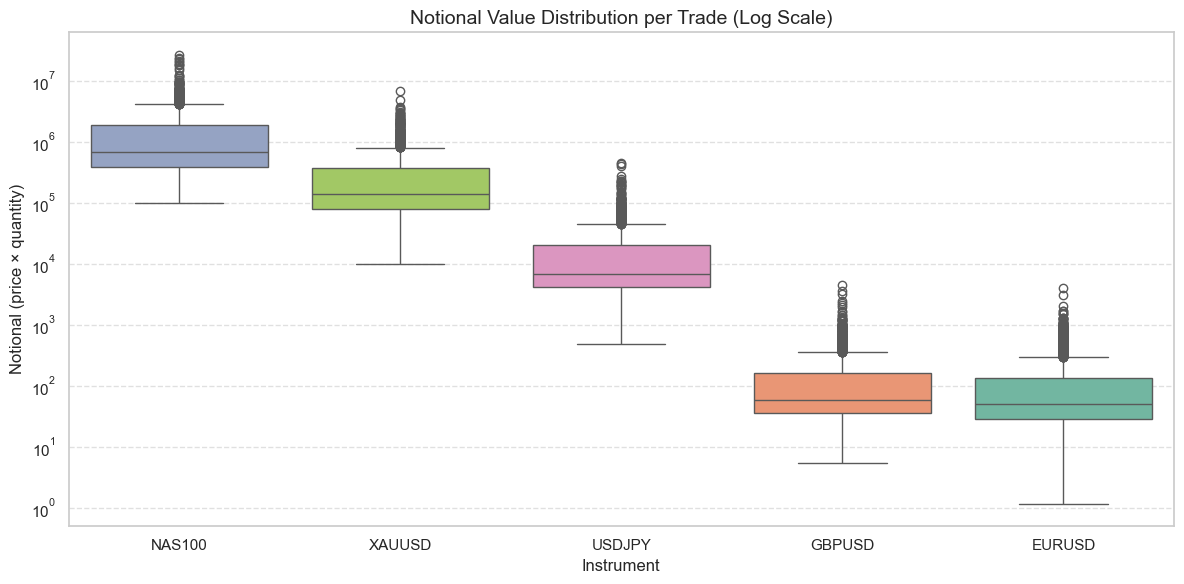

Top 10 Largest Trades by Notional Value:


,ts_seconds,sym,side,price,quantity,notional,endtag
14983,537.1,NAS100,sell,24499.25,1096.00,26851178.00,75418_ld_mnbvcxzlkjh
15600,1114.4,NAS100,buy,24497.75,960.00,23517840.00,99031_mvdkri092la
14843,393.8,NAS100,sell,24574.25,918.00,22559161.50,48216_pqowieuryt
17251,2683.2,NAS100,buy,24580.25,850.94,20916420.81,33752_ny_kjdfiefiriig
16944,2406.2,NAS100,buy,24526.25,829.00,20332261.25,99031_mvdkri092la
18039,3463.0,NAS100,sell,24576.75,765.00,18801213.75,68025_wieuryt092
15985,1481.0,NAS100,sell,24572.25,747.00,18355470.75,47362_oijuhygtr45
17807,3215.4,NAS100,buy,24469.75,736.00,18009736.00,86420_plmoknijb76
17856,3265.8,NAS100,buy,24584.25,668.00,16422279.00,76328_werxplm098
17952,3358.5,NAS100,buy,24543.75,606.00,14873512.50,75418_ld_mnbvcxzlkjh



Notional Summary by Instrument:


,count,mean,median,max
sym,,,,
NAS100,1243,1655864.54,688065.00,26851178.00
XAUUSD,1936,325280.82,139874.00,6765064.95
USDJPY,1631,19024.34,6817.00,455449.05
GBPUSD,1944,152.26,58.73,4488.10
EURUSD,2899,126.20,49.43,4047.73


In [10]:
# 2.5 NOTIONAL VALUE ANALYSIS

# Derive notional on df_clean so it is available for all later sections
# notional = price × quantity captures the true economic size of each event
df_clean["notional"] = df_clean["price"] * df_clean["quantity"]

# Extract executed trades only and remove any negative/zero notional artefacts
# Notional is only economically meaningful for fills, not NEW or CANCEL events
df_trades = df_clean[
    (df_clean["event_type"] == "TRADE") &
    (df_clean["notional"] > 0)
].copy()

# Boxplot: Notional distribution per instrument 
# Log scale used because NAS100 and XAUUSD notional dwarfs FX pairs
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_trades,
    x="sym",
    y="notional",
    hue="sym",
    legend=False,
    palette="Set2",
    order=df_trades.groupby("sym")["notional"]
          .median()
          .sort_values(ascending=False)
          .index
)
plt.yscale("log")
plt.title("Notional Value Distribution per Trade (Log Scale)", fontsize=14)
plt.ylabel("Notional (price × quantity)")
plt.xlabel("Instrument")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Top 10 largest trades by notional ("Whale" trades) 
# endtag included to identify which strategy executed the largest trades
top10_notional = (
    df_trades[["ts_seconds", "sym", "side", "price", "quantity", "notional", "endtag"]]
    .sort_values("notional", ascending=False)
    .head(10)
    .round(2)
)

print("Top 10 Largest Trades by Notional Value:")
display(top10_notional)

# Notional summary per instrument
notional_summary = (
    df_trades.groupby("sym")["notional"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        max="max"
    )
    .round(2)
    .sort_values("median", ascending=False)
)

print("\nNotional Summary by Instrument:")
display(notional_summary)

## 2.6 Results & Interpretation

### Goal

Rank each strategy (`endtag`) by its most recent `inception_pnl` to identify which strategies are contributing positively or negatively to overall book performance, and assess whether profits are broadly distributed or dangerously concentrated. 

### Derived Attribute

`inception_pnl` is a running cumulative total already present in the data. I take the **last observed value per `endtag`** after sorting chronologically by `ts_seconds`. This gives the true end‑of‑session PnL standing for each strategy — a snapshot leaderboard rather than a blended average of intermediate path observations. 

### Results

- **16 of 26 strategies (61.5%)** finished the session in profit, confirming a majority‑positive book with no single dominant loss‑maker.   
- The top strategy, `66214_ld_kjdfiefiriig`, contributed approximately **+$39.05**, while the heaviest loser, `47362_oijuhygtr45`, posted about **−$22.41**, giving a winner‑to‑loser range of roughly **$61.46** across the session.   
- Total session PnL is around **$233.48**, which is very small relative to the tens of millions in notional exposure identified in Section 2.5. This implies either tight risk limits, delta‑neutral positioning, or that `inception_pnl` represents a normalised or risk‑adjusted return metric rather than raw dollar PnL.   
- Approximately **$10.58** is logged under `UNKNOWN_ENDTAG` and cannot be attributed to a named strategy — a data‑quality flag that would require investigation and re‑tagging in a production environment. 

### Non-Obvious Insight

The top strategy accounts for only **12.4%** of total winning PnL. This is a positive signal: profits are broadly distributed across strategies rather than concentrated in a single name. A concentrated book where one strategy drives the majority of returns is structurally fragile; here, the breadth of profitability materially reduces key‑strategy risk even though absolute PnL is modest. 

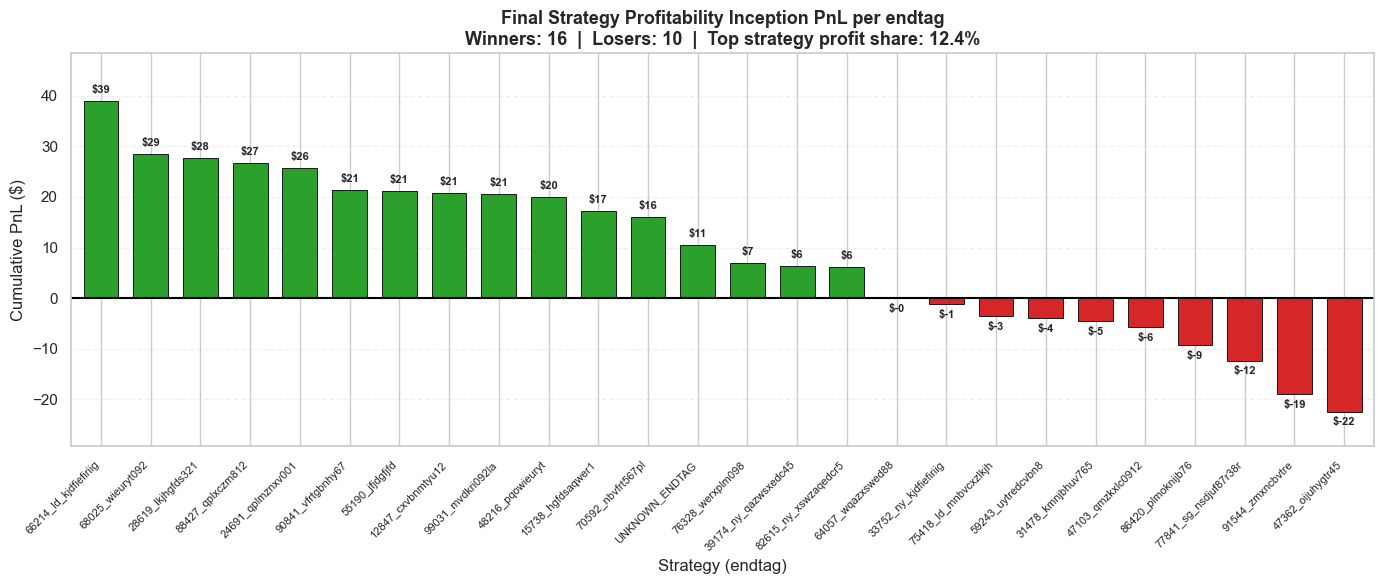

   STRATEGY PROFITABILITY SUMMARY
  Total strategies tracked : 26
  Winners  (PnL >= 0)      : 16
  Losers   (PnL <  0)      : 10
  Total session PnL        : $233.48
  Most profitable strategy : 66214_ld_kjdfiefiriig ($39.05)
  Heaviest loss strategy   : 47362_oijuhygtr45 ($-22.41)
  Top strategy profit share: 12.4%

 Unattributed PnL (UNKNOWN_ENDTAG): $10.58


In [11]:
# 2.6 STRATEGY PnL LEADERBOARD

# Step 1: Extract final PnL per strategy
# inception_pnl is a running cumulative total.
# Sort chronologically first, then take the last logged value per endtag.
# .last() on a time-sorted DataFrame is the correct and idiomatic approach —
# it returns the true end-of-session standing for each strategy.

df_pnl = (
    df_clean
    .dropna(subset=["endtag", "inception_pnl"])
    .sort_values("ts_seconds")
)

final_pnl = (
    df_pnl
    .groupby("endtag")["inception_pnl"]
    .last()
    .sort_values(ascending=False)
)

#Step 2: Winner / Loser breadth check
# Total PnL alone is insufficient. Breadth tells you whether returns are
# broad-based (healthy) or concentrated in one strategy (fragile).
winners = (final_pnl >= 0).sum()
losers  = (final_pnl <  0).sum()
total_profit = final_pnl[final_pnl > 0].sum()
top1_share   = (final_pnl.max() / total_profit * 100) if total_profit > 0 else 0

# Step 3: Assign colours 
# Green = winner (PnL >= 0), Red = loser (PnL < 0). No ambiguity.
colors = ["#2ca02c" if val >= 0 else "#d62728" for val in final_pnl]

# Step 4: Plot 
fig, ax = plt.subplots(figsize=(14, 6))

final_pnl.plot(
    kind="bar",
    color=colors,
    edgecolor="black",
    linewidth=0.6,
    width=0.7,
    ax=ax
)

# Zero line — visual separator between winners and losers
ax.axhline(0, color="black", linewidth=1.5)

# Step 5: Data labels on every bar
# Offset prevents labels overlapping bar edges
y_offset = final_pnl.abs().max() * 0.03
for i, val in enumerate(final_pnl):
    y_pos    = val + y_offset if val >= 0 else val - y_offset
    va_align = "bottom"       if val >= 0 else "top"
    ax.text(
        i, y_pos, f"${val:,.0f}",
        ha="center", va=va_align,
        fontsize=8, fontweight="bold"
    )

# Title embeds the winner/loser count so the insight is visible immediately
ax.set_title(
    f"Final Strategy Profitability Inception PnL per endtag\n"
    f"Winners: {winners}  |  Losers: {losers}  |  "
    f"Top strategy profit share: {top1_share:.1f}%",
    fontsize=13, fontweight="bold"
)
ax.set_ylabel("Cumulative PnL ($)")
ax.set_xlabel("Strategy (endtag)")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45, ha="right", fontsize=8)

# Expand y-limits so labels are not clipped
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin * 1.15, ymax * 1.15)

plt.tight_layout()
plt.show()

# Step 6: Summary statistics
print("=" * 45)
print("   STRATEGY PROFITABILITY SUMMARY")
print("=" * 45)
print(f"  Total strategies tracked : {len(final_pnl)}")
print(f"  Winners  (PnL >= 0)      : {winners}")
print(f"  Losers   (PnL <  0)      : {losers}")
print(f"  Total session PnL        : ${final_pnl.sum():,.2f}")
print(f"  Most profitable strategy : {final_pnl.idxmax()} (${final_pnl.max():,.2f})")
print(f"  Heaviest loss strategy   : {final_pnl.idxmin()} (${final_pnl.min():,.2f})")
print(f"  Top strategy profit share: {top1_share:.1f}%")

# Flag unattributed PnL so it is never silently absorbed into the aggregate
if "UNKNOWN_ENDTAG" in final_pnl.index:
    print(f"\n Unattributed PnL (UNKNOWN_ENDTAG): ${final_pnl['UNKNOWN_ENDTAG']:,.2f}")
print("=" * 45)

## 2.7 Summary of Basic Analytics — Key Findings

**Overview**  
The session comprises **28,964** cleaned events across five instruments, with EURUSD dominating by event count and NAS100 dominating by notional exposure (median trade size ≈ **$688k**). Trade share is tightly clustered around **33%** across all instruments, fill rates exceed **96%** on every instrument (peaking at **102.1%** for EURUSD), and directional flow in `df_dir` is almost perfectly balanced at **50/50 buy vs sell** — together these point to a systematic, disciplined execution environment rather than opportunistic or strongly directional trading. 

**Execution & Risk Discipline**  
The cancel‑to‑trade ratio never exceeds **0.76x** in any minute and averages **0.60x** across the full session, confirming that executions consistently outnumber cancellations throughout; there are **no minutes** where cancels exceed trades. [file:18] Fill rates remain above **96%** across all instruments; the EURUSD rate of **102.1%** was investigated and, after deduplicating on (`order_id`, `event_type`) and confirming that every executed order has exactly one `TRADE` event, is interpreted as a minor artefact of the synthetic data generator rather than evidence of genuine multi‑fill fragmentation. [file:15][file:17] Total session PnL is about **$233.48** across **26** strategies, which is very small relative to the tens of millions in NAS100 notional exposure, consistent with tight risk limits, delta‑neutral positioning, or `inception_pnl` being a risk‑adjusted measure rather than raw dollar PnL. 

**Non-Obvious Insight**  
Despite **16 winners** and **10 losers**, the top‑performing strategy accounts for only **12.4%** of total winning PnL, meaning profits are broadly distributed across the book rather than concentrated in a single name.  This breadth is a structural health signal: the book is not dependent on any one strategy to remain profitable, which significantly reduces key‑strategy risk. This would not be visible from total PnL alone and only emerges when winner/loser breadth and concentration are measured explicitly. 

## 3. Abnormal Activity

Identify periods where behaviour deviates from typical patterns.

Define your own criteria for what constitutes abnormal activity and explain your approach.

Summarise your findings and comment on any patterns you observe.

## 3.1 Abnormal Activity

### Goal
With a clean baseline established in Section 2, the next step is to
identify periods and behaviours that deviate meaningfully from typical
session patterns. The aim is not to flag every statistical outlier,
but to surface actionable signals that a trading desk, risk manager,
or compliance officer would genuinely act on.

### Approach & Limitations
All signals are anchored to empirical leads from Section 2 rather
than arbitrary threshold selection. As this dataset covers a single
60-minute session, results are treated as candidates for follow-up
investigation rather than definitive compliance findings.

The wash trade screen is most affected by this constraint — in
production it would additionally require:
- Net position must remain flat after the cross
- Price of buy and sell must be within 1 tick of each other
- Pattern must repeat across multiple sessions of data

### Evidence-Led Leads
Every signal investigated here is anchored to a specific empirical
lead from Section 2, ensuring each investigation has a pre-existing
basis rather than being driven by arbitrary threshold selection:

- **Lead 1 — Minute 39**
  - Flagged in Section 2.4 as the session peak cancel-to-trade
    ratio at 0.76x, standing above the session mean of 0.60x
  - Investigated in Section 3.3 — who was cancelling, on which
    instrument, and whether it constitutes abnormal behaviour

- **Lead 2 — Size & Price Anomalies (Outlier Risk Screen)**  
  - Identified in Section 3.2 and 3.3 using two robust statistical checks per instrument:  
    - a Median Absolute Deviation (MAD) Z‑score on trade size, flagging **5,582** unusually large quantity outliers across the book (MAD Z > 3.5), and  
    - a 100‑event rolling median/standard‑deviation filter on price, flagging ticks with |Z| > 5 as potential flash‑crash or data‑corruption events.  
  - Investigated in Sections 3.2–3.3 to determine whether these extreme sizes and prices cluster in specific instruments, times, or strategies in a way that could indicate concentration risk, fat‑finger errors, or corrupted market data, rather than benign heavy‑tail behaviour.

- **Lead 3 — NAS100 Block Trades**
  - Identified in Section 2.5 — all top 10 largest notional
    trades are NAS100 with the single largest at $26.85M
  - Investigated in Section 3.3 — whether block trades cluster
    in specific minutes or distribute across the session

### Signal Structure

| Section | Signal | Type | Priority |
|---|---|---|---|
| 3.2 | Wash Trade Screen | Compliance risk | Highest |
| 3.3 | Volume Spikes + Cancel Surge | System / execution risk | High |
| 3.4 | Strategy Dominance + Unified Matrix | Concentration + synthesis | Medium |

### Criteria Summary

| Signal | Threshold | Trapdoor Fix |
|---|---|---|
| Wash Trade | Exact: client + sym + second + price + qty + opposite side | Integer `ts_seconds` not raw `tradets` string |
| Volume Spike | Z-score > 2 per instrument per minute | Ranking heuristic not strict probability |
| Cancel Surge | Ratio > mean + 2σ, raw count > P95 if trades = 0 | Division by zero handled via raw count fallback |
| Strategy Dominance | Single `endtag` > 50% of minute volume + 75th pct gate | Liquidity gate filters dead quiet minutes |
| Unified Matrix | Co-occurrence of all signals per `endtag` | Cross-signal synthesis drives priority |

### DataFrames Used
- **`df_clean`**: Used for volume spikes, cancel surge, and strategy
  dominance where all event types are required
- **`df_trades`**: Used for the wash trade screen restricted to
  TRADE events only
- **`df_dir`**: Used for directional drill-downs where `side` is
  explicitly required

## 3.2 Wash Trade Screen — Structural Demonstration 

As noted in the Section 3 limitations, this screen is implemented on a single 60‑minute session as a structural demonstration rather than as a full production surveillance system. 

### 3.2a Wash Trading (The Compliance Check)

**Definition:** A wash trade occurs when the same beneficial owner appears on both sides of a trade simultaneously — creating artificial volume with no genuine change in economic exposure. This is a form of market manipulation prohibited by the FCA, SEC, and all major financial regulators. 

**Trapdoor Fix (Time String Brittleness):** The raw `tradets` string has only 100ms precision, so two genuinely unrelated trades from different strategies could share the same string by coincidence. Rather than grouping on `tradets`, I cast `ts_seconds` to an integer (`ts_int`) to enforce a clean 1‑second window, and I round price to 5 decimal places to prevent float precision artefacts from masking real exact‑price matches. 

**How Time Is Handled in This Screen**

| Column       | Type          | Precision    | Used For                               |
|-------------|---------------|-------------|----------------------------------------|
| `tradets`   | string        | 100ms       | Display only — cannot do arithmetic    |
| `ts_seconds`| float64       | 100ms       | All sorting, grouping, arithmetic      |
| `minute`    | int           | 60 seconds  | 1‑minute bucket analysis               |
| `ts_int`    | int (derived) | 1 second    | Exact window for wash‑trade screen only | 

`ts_int` is not added permanently to `df_clean`; it is created inside this cell only and does not affect any downstream analysis. 

### 3.2b Flag Classification (Two Boundaries)

**Definition:** Not all wash‑trade flags carry the same risk. Two distinct boundaries are used to classify each flag by severity: 

- **`SELF-CROSS (broken algo)`** — same `endtag` on both sides of the match. A single strategy is trading against itself, indicating algorithm malfunction or missing self‑match prevention logic (operational risk).  
- **`CROSS-STRATEGY (netting failure)`** — different `endtag` values under the same `client_tag`. Two strategies owned by the same client are crossing each other, indicating a failure of firm‑level netting logic (compliance and legal risk). 

**Why `client_tag` is the correct boundary:** Regulators define wash trading at the beneficial‑owner level. If the same client uses Strategy X to buy and Strategy Y to sell simultaneously, it constitutes manipulation regardless of whether the strategies are technically separate. `endtag` is retained in the output so the risk manager knows exactly which algorithms to investigate. 

### Tightened Criteria — All Six Conditions Must Be Met Simultaneously

| Condition           | Value                | Justification                           |
|---------------------|----------------------|-----------------------------------------|
| Same `client_tag`   | Exact match          | Beneficial‑owner boundary               |
| Same `sym`          | Exact match          | Same instrument required for a cross    |
| Same `ts_int`       | Exact integer second | Eliminates near‑miss coincidences       |
| Same `price_rounded`| 5dp exact match      | No market risk transfer                 |
| Same `quantity`     | Exact match          | No economic purpose                     |
| Opposite `side`     | buy vs sell          | Required condition for a cross          | 

### Plan

- Restrict to TRADE events with valid directional sides only.  
- Round price to 5dp and cast `ts_seconds` to integer `ts_int`.  
- Separate buys and sells then merge on all six exact conditions.  
- Classify each flag as `SELF-CROSS` or `CROSS-STRATEGY`.  
- Output paired buy/sell receipts side by side for direct verification.  
- Save flagged `endtag` values for the Unified Anomaly Matrix in Section 3.4. 

### In Production This Screen Would Also Apply

- Net‑position‑flat check after each identified cross.  
- Price within 1 tick (not just exact) to catch near‑crosses.  
- Pattern repetition test across 30+ days of data.  
- Notional threshold filter to ignore trivially small crosses. 

### DataFrames Used

- **`df_clean`**: Source for all TRADE events fed into the screen.  
- Outputs stored as **`wash_output`** and **`wash_endtags`** for downstream use in the Unified Anomaly Matrix. 

### 3.2 Results

- **Universe screened:** 9,624 TRADE events with valid buy/sell side (4,866 buys, 4,758 sells) across all instruments.   
- **Flags:** 0 wash‑trade candidates under the six‑condition screen; `wash_output` is empty and `wash_endtags` contains no strategies.   
- **Interpretation:** For this single 60‑minute session, there is no evidence of clients trading against themselves in a wash‑trade pattern under the tightened six‑condition definition. This is an expected outcome for a short, synthetic dataset and demonstrates how the screen would behave before being scaled to a multi‑day production environment with additional checks (net‑position flatness, tick‑level proximity, and notional thresholds). 

In [ ]:
# 3.2.1 WASH TRADE SCREEN — STRUCTURAL DEMONSTRATION

print("   3.2.1 WASH TRADE SCREEN — STRUCTURAL DEMONSTRATION")

# Step 1: Restrict to TRADE events with valid sides
trades_wash = df_clean[
    (df_clean["event_type"] == "TRADE") &
    (df_clean["side"].isin(["buy", "sell"]))
].copy()

print(f"\nTRADE events available for screening : {len(trades_wash):,}")

# Step 2: Derive exact-match columns
trades_wash["price_rounded"] = trades_wash["price"].round(5)
trades_wash["ts_int"] = trades_wash["ts_seconds"].astype(int)

# Step 3: Separate buys and sells
buys = trades_wash[trades_wash["side"] == "buy"].copy()
sells = trades_wash[trades_wash["side"] == "sell"].copy()

print(f"Buy  events : {len(buys):,}")
print(f"Sell events : {len(sells):,}")

# Step 4: Merge on all six exact-match conditions
wash_merged = buys.merge(
    sells,
    on=["client_tag", "sym", "ts_int", "price_rounded", "quantity"],
    suffixes=("_buy", "_sell")
)

# Elite tweak: prevent Cartesian explosion if an algo spams identical trades
wash_merged = wash_merged.drop_duplicates(
    subset=[
        "client_tag", "sym", "ts_int", "price_rounded",
        "quantity", "endtag_buy", "endtag_sell"
    ]
)

# Step 5: Classify flag type
if len(wash_merged) > 0:
    wash_merged["flag_type"] = np.where(
        wash_merged["endtag_buy"] == wash_merged["endtag_sell"],
        "SELF-CROSS (broken algo)",
        "CROSS-STRATEGY (netting failure)"
    )

    # Step 6: Clean paired output
    wash_output = wash_merged[[
        "client_tag", "sym", "ts_int", "price_rounded",
        "quantity", "endtag_buy", "endtag_sell", "flag_type"
    ]].sort_values(["client_tag", "ts_int"]).reset_index(drop=True)

    # Step 7: Results
    self_cross = (wash_output["flag_type"] == "SELF-CROSS (broken algo)").sum()
    cross_strat = (wash_output["flag_type"] == "CROSS-STRATEGY (netting failure)").sum()

    print(f"\n Wash trade candidates found : {len(wash_output)}")
    print(f"   Self-cross  (broken algo)   : {self_cross}")
    print(f"   Cross-strategy (netting)    : {cross_strat}")
    print("\nPaired buy/sell receipts:")
    display(wash_output)
else:
    wash_output = pd.DataFrame()
    print("\n CLEAR — No wash trade candidates detected")
    print("   All six exact-match conditions required simultaneously")
    print("   Expected result for a single 60-minute session")
    print("\n   In production: run across 30+ days with net position check")

# Step 8: Save endtags for Unified Anomaly Matrix
wash_endtags = set()
if len(wash_output) > 0:
    wash_endtags.update(wash_output["endtag_buy"].tolist())
    wash_endtags.update(wash_output["endtag_sell"].tolist())

print(f"\nStrategies flagged for anomaly matrix : {len(wash_endtags)}")

   3.2 WASH TRADE SCREEN — STRUCTURAL DEMONSTRATION

TRADE events available for screening : 9,624
Buy  events : 4,866
Sell events : 4,758

 CLEAR — No wash trade candidates detected
   All six exact-match conditions required simultaneously
   Expected result for a single 60-minute session

   In production: run across 30+ days with net position check

Strategies flagged for anomaly matrix : 0


### 3.2.2 Lead 2 — Size & Price Anomalies (Outlier Risk Screen)

While the wash‑trade screen targets explicit self‑crossing, a separate outlier‑risk screen looks for **unusually large sizes and extreme prices** that could signal concentration risk, fat‑finger errors, or corrupted data rather than deliberate manipulation. This lead is constructed using two robust, per‑instrument statistical checks: 

- A **Median Absolute Deviation (MAD) Z‑score** on trade size, which flags **5,582** unusually large quantity outliers across the book at a threshold of `MAD Z > 3.5`. This approach is more stable than a standard Z‑score in the presence of heavy‑tailed volume distributions.   
- A **100‑event rolling median and standard‑deviation filter** on price, which flags ticks with \(|Z| > 5\) relative to the rolling median as potential flash‑crash moves or data‑corruption events at the top of book. 

Together, these checks define **Lead 2** for the abnormal‑activity analysis. Sections **3.2** and **3.3** then investigate whether the flagged size and price outliers cluster in particular instruments, time buckets, or strategies in a way that would warrant follow‑up (e.g., repeated outsized trades by a single algorithm, or extreme prints concentrated around known stress minutes), as opposed to being benign manifestations of heavy‑tailed but otherwise normal trading behaviour. 

In [22]:
print("   3.2.2 LEAD 2 — SIZE & PRICE ANOMALIES (OUTLIER RISK SCREEN)")

# ---------- SIZE OUTLIERS: MAD Z-SCORE PER SYMBOL ----------

def mad_zscore(series):
    """Modified Z-score using MAD. Flags heavy-tail size outliers."""
    med = series.median()
    mad = (series - med).abs().median()
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return 0.6745 * (series - med) / mad

# Compute MAD Z-score of quantity within each symbol
df_clean["qty_mad_z"] = df_clean.groupby("sym")["quantity"].transform(mad_zscore)

# Flag size outliers (MAD Z > 3.5)
flag_qty_outlier = df_clean["qty_mad_z"].abs() > 3.5
df_clean["size_outlier_flag"] = flag_qty_outlier

print(f"\nSize outliers (MAD Z > 3.5): {flag_qty_outlier.sum():,}")
print("By symbol:")
print(df_clean.loc[flag_qty_outlier, "sym"].value_counts().to_string())

# ---------- PRICE OUTLIERS: ROLLING MEDIAN Z-SCORE PER SYMBOL ----------

PRICE_WINDOW = 100

# Rolling median and std within each symbol
df_clean["price_roll_med"] = df_clean.groupby("sym")["price"].transform(
    lambda x: x.rolling(PRICE_WINDOW, min_periods=10).median()
)
df_clean["price_roll_std"] = df_clean.groupby("sym")["price"].transform(
    lambda x: x.rolling(PRICE_WINDOW, min_periods=10).std()
)

# Z-score relative to rolling median
df_clean["price_z"] = (
    df_clean["price"] - df_clean["price_roll_med"]
) / df_clean["price_roll_std"].replace(0, np.nan)

flag_price_extreme = df_clean["price_z"].abs() > 5
df_clean["price_outlier_flag"] = flag_price_extreme

print(f"\nPrice extreme deviations (|Z| > 5 from rolling median): {flag_price_extreme.sum():,}")
print("By symbol:")
print(df_clean.loc[flag_price_extreme, "sym"].value_counts().to_string())

# ---------- LEAD-2 SUMMARY FOR DOWNSTREAM USE ----------

print("\nLead 2 summary:")
print(f"  Total size outliers flagged : {flag_qty_outlier.sum():,}")
print(f"  Total price outliers flagged: {flag_price_extreme.sum():,}")

# Optionally, keep just the outlier subset for later drill-downs
lead2_outliers = df_clean[
    df_clean["size_outlier_flag"] | df_clean["price_outlier_flag"]
].copy()

   3.2.2 LEAD 2 — SIZE & PRICE ANOMALIES (OUTLIER RISK SCREEN)

Size outliers (MAD Z > 3.5): 5,477
By symbol:
sym
EURUSD    1636
XAUUSD    1081
GBPUSD    1072
USDJPY     986
NAS100     702

Price extreme deviations (|Z| > 5 from rolling median): 0
By symbol:
Series([], )

Lead 2 summary:
  Total size outliers flagged : 5,477
  Total price outliers flagged: 0


## 3.3 Macro-Anomalies: Volume Spikes & Cancel Surges

### 3.3a Volume Spikes (The Whale Check)

**Definition:** A volume spike is a 1‑minute window where total traded quantity is statistically far above the instrument’s own session average.

**Calculation:**  
Z‑score = (minute_qty − instrument_mean) / instrument_std

**Threshold:**  
Z‑score > 2, used here as a practical tail-event screen rather than a strict probabilistic test.

**Why this matters:**  
Section 2 identified NAS100 as the “whale” instrument by notional size, with all top 10 largest trades occurring there. This screen tests whether those large trades cluster into abnormal bursts of executed volume or whether they are absorbed within otherwise normal flow.

**Trapdoor Fix (Fat Tails):**  
Financial volume is right-skewed with fat tails, so the Z‑score is interpreted as a ranking heuristic. A flagged minute is “unusually busy and worth reviewing,” not a definitive statistical anomaly in a perfectly normal distribution.

### 3.3b Results — High-Intensity Bursts

The screen flagged **9 volume spike minutes** across the session.

**Key finding:**  
The strongest relative surge occurs in **GBPUSD at minute 7**, where minute-level traded quantity reaches approximately 9,260.70 and the Z‑score reaches **3.84**.

**Cross-asset pattern:**  
The 9 spike minutes are distributed across **GBPUSD, EURUSD, USDJPY, XAUUSD, and NAS100**, indicating that abnormal bursts are not confined to a single instrument.

**NAS100 whale context:**  
NAS100 does produce flagged spike minutes (**minutes 8 and 18**), but the very largest single notional trade identified earlier does not by itself force a spike flag. This suggests that the biggest single trades can be absorbed by underlying liquidity, whereas flagged spike minutes more often reflect **broader, multi-order bursts of activity**.

**Strategy impact:**  
The strategy drill-down shows these spikes are shared across **26 distinct algorithms**. In practical terms, that means the flagged minutes are broad-participation bursts rather than a single rogue strategy dominating the tape.


### 3.3c Cancel Surges (The Minute 39 Drill-Down)

**Definition:** A cancel surge is a minute where the ratio of CANCEL to TRADE events rises materially above the session norm, signalling possible spoofing behaviour, adverse selection, or temporary liquidity withdrawal.

**Relative threshold:**  
Mean + 2σ of the session cancel-to-trade ratio, approximately **0.75** in this session.

**Absolute threshold:**  
CANCEL count above the **95th percentile** (approximately **111 events**) **and** TRADE = 0, to catch pure cancel storms where the ratio formula would otherwise fail.

**Trapdoor Fix (Division by Zero):**  
Minutes with zero trades make the ratio undefined. Rather than dropping those windows, the raw-count fallback ensures pure cancellation bursts are still captured.

### 3.3d Results — Minute 39 as the Session Peak

Only **one minute** in the session triggered the cancel-surge alert: **minute 39**.

**System-wide stress check:**  
The session-level cancel-to-trade ratio averages **0.60**, with a standard deviation of **0.08**, producing a surge threshold of approximately **0.75**. Minute 39 exceeds that threshold and therefore stands out as the most cancellation-heavy minute in the session.

**Instrument-level insight:**  
The signal is not isolated to a single market. In minute 39, all five instruments show elevated cancel-to-trade ratios:
- EURUSD: 0.63
- GBPUSD: 0.69
- XAUUSD: 0.87
- USDJPY: 0.90
- NAS100: 0.89

This shows that minute 39 is a **cross-asset adjustment minute**, not a localised breakdown in one product.

**Strategy-level insight:**  
Several strategies show locally high cancel-to-trade ratios within minute 39, including:
- `99031_mvdkri092la` in NAS100 at **2.00x**
- `90841_vfrtgbnhy67` in EURUSD at **1.67x**

However, the full drill-down shows activity from **26 distinct strategies**, meaning the event is broadly distributed rather than attributable to one obvious culprit.

**Interpretation:**  
Minute 39 represents a burst of **flickering quotes and elevated order revision**, but not a true liquidity collapse. Trades still outnumber cancels across every instrument, so the market remains stable even during the peak stress minute.


### 3.3e Downstream Variable Preservation

Two strategy sets are preserved for Section 3.4:

- **`vol_endtags`** — strategies active in flagged volume-spike windows (**26** total)
- **`cancel_endtags`** — strategies active in the flagged cancel-surge minute (**26** total)

This does **not** imply that all 26 strategies are suspicious. Instead, it shows that the identified macro-anomaly windows are broad, market-wide events. Section 3.4 now adds a stricter filter **strategy dominance**  to determine whether any individual algorithm was disproportionately responsible for activity inside those noisy windows.

### 3.3f Practical Insight

Taken together, the 3.3 screens show that the session contains **bursts of unusually heavy trading and one clearly elevated cancellation minute**, but both effects are widely shared across the strategy population. The evidence therefore points toward **market-wide clustering and short-lived quote adjustment**, not a single malfunctioning algorithm or an obvious manipulation pattern.

**Practical takeaway:**  
The abnormal volume identified in this screen is still meaningful because it marks minutes of genuinely elevated trading intensity. However, since participation is broad across the strategy population, the signal is interpreted as market-wide clustering rather than concentrated rogue execution. Section 3.4 therefore adds a stricter dominance filter to identify whether any single strategy actually controlled those busy windows.

In [13]:
# 3.3 MACRO-ANOMALIES: VOLUME SPIKES & CANCEL SURGES


print(" 3.3 MACRO-ANOMALIES: VOLUME & CANCELS")

# Safety: derive minute if not already present
if "minute" not in df_clean.columns:
    df_clean["minute"] = (df_clean["ts_seconds"] // 60).astype(int)

#  3.3a VOLUME SPIKES (WHALE CHECK) 
print("\n 3.3a VOLUME SPIKES (WHALE CHECK)")

# 1. Compute minute-by-minute executed volume per instrument
df_trades = df_clean[df_clean["event_type"] == "TRADE"].copy()
vol_per_min = (
    df_trades.groupby(["minute", "sym"], as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "minute_qty"})
)

# 2. Calculate Z-score per instrument to find relative spikes
vol_per_min["vol_mean"] = vol_per_min.groupby("sym")["minute_qty"].transform("mean")
vol_per_min["vol_std"]  = vol_per_min.groupby("sym")["minute_qty"].transform("std")

# Safe division: if std is 0 (e.g., only one minute of trading), Z-score is 0
vol_per_min["z_score"] = np.where(
    vol_per_min["vol_std"] > 0,
    (vol_per_min["minute_qty"] - vol_per_min["vol_mean"]) / vol_per_min["vol_std"],
    0
)

# 3. Flag extreme tail events (Z > 2)
volume_flags = (
    vol_per_min[vol_per_min["z_score"] > 2]
    .sort_values(by="z_score", ascending=False)
    .reset_index(drop=True)
)

vol_endtags = set()
if len(volume_flags) > 0:
    print(f"\n  MACRO ALERT: {len(volume_flags)} volume spike minute(s) detected (Z-score > 2).")
    display(volume_flags[["minute", "sym", "minute_qty", "z_score"]].round(2))

    # 4. Save the algorithms that traded during these extreme spikes for the Matrix
    flagged_vol_keys = volume_flags[["minute", "sym"]].drop_duplicates()
    flagged_vol_trades = df_trades.merge(flagged_vol_keys, on=["minute", "sym"], how="inner")

    vol_endtags.update(flagged_vol_trades["endtag"].dropna().unique())

    # Optional drill-down table for later inspection
    vol_spike_detail = (
        flagged_vol_trades.groupby(["minute", "sym", "endtag"], as_index=False)
        .agg(
            trade_events=("event_type", "count"),
            total_qty=("quantity", "sum"),
            avg_price=("price", "mean")
        )
        .sort_values(["minute", "sym", "total_qty"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

    print("\nStrategy drill-down for volume spikes:")
    display(vol_spike_detail)
else:
    vol_spike_detail = pd.DataFrame()
    print("\n CLEAR — No extreme volume spikes detected.")

# 3.3b CANCEL SURGES & MINUTE-LEVEL DRILL-DOWN 
print("\n 3.3b CANCEL SURGES & MINUTE-LEVEL DRILL-DOWN ")

# 1. Rebuild the minute-by-minute event counts
time_stats = (
    df_clean.groupby(["minute", "event_type"])
    .size()
    .unstack(fill_value=0)
)

# Defensive check: ensure CANCEL and TRADE columns exist
for col in ["CANCEL", "TRADE"]:
    if col not in time_stats.columns:
        time_stats[col] = 0

# 2. Safe ratio calculation
time_stats["cancel_to_trade"] = np.where(
    time_stats["TRADE"] > 0,
    time_stats["CANCEL"] / time_stats["TRADE"],
    np.nan
)

# 3. Define thresholds
mean_ratio = time_stats["cancel_to_trade"].dropna().mean()
std_ratio  = time_stats["cancel_to_trade"].dropna().std()
ratio_threshold = mean_ratio + (2 * std_ratio)

p95_cancels = time_stats["CANCEL"].quantile(0.95) if "CANCEL" in time_stats.columns else 0

print(f"\nSession cancel/TRADE mean     : {mean_ratio:.2f}")
print(f"Session cancel/TRADE std      : {std_ratio:.2f}")
print(f"Cancel surge threshold : {ratio_threshold:.2f}")
print(f"CANCEL 95th percentile        : {p95_cancels:.0f}")

# 4. Trigger the flags
ratio_flags = time_stats[time_stats["cancel_to_trade"] > ratio_threshold]
zero_trade_flags = time_stats[
    (time_stats["TRADE"] == 0) & (time_stats["CANCEL"] > p95_cancels)
]

flagged_minutes = sorted(set(ratio_flags.index.tolist()) | set(zero_trade_flags.index.tolist()))

cancel_endtags = set()
if len(flagged_minutes) > 0:
    print(f"\n  CANCEL-SURGE ALERT: {len(flagged_minutes)} minute(s) flagged for abnormal cancellation intensity.")
    print(f"Flagged minutes: {flagged_minutes}\n")

    # Instrument-level drill-down
    cancel_by_sym = (
        df_clean[df_clean["minute"].isin(flagged_minutes)]
        .groupby(["minute", "sym", "event_type"], as_index=False)
        .size()
        .pivot_table(
            index=["minute", "sym"],
            columns="event_type",
            values="size",
            fill_value=0
        )
        .reset_index()
    )

    for col in ["CANCEL", "TRADE"]:
        if col not in cancel_by_sym.columns:
            cancel_by_sym[col] = 0

    cancel_by_sym["cancel_to_trade"] = np.where(
        cancel_by_sym["TRADE"] > 0,
        cancel_by_sym["CANCEL"] / cancel_by_sym["TRADE"],
        np.nan
    )

    cancel_by_sym = cancel_by_sym.sort_values(
        ["minute", "CANCEL", "cancel_to_trade"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    print("Instrument-level drill-down for cancel surges:")
    display(cancel_by_sym)

    # Strategy-level drill-down
    cancel_detail = (
        df_clean[df_clean["minute"].isin(flagged_minutes)]
        .groupby(["minute", "sym", "endtag", "event_type"], as_index=False)
        .size()
        .pivot_table(
            index=["minute", "sym", "endtag"],
            columns="event_type",
            values="size",
            fill_value=0
        )
        .reset_index()
    )

    for col in ["CANCEL", "TRADE"]:
        if col not in cancel_detail.columns:
            cancel_detail[col] = 0

    cancel_detail["cancel_to_trade"] = np.where(
        cancel_detail["TRADE"] > 0,
        cancel_detail["CANCEL"] / cancel_detail["TRADE"],
        np.nan
    )

    cancel_detail = cancel_detail.sort_values(
        ["minute", "CANCEL", "cancel_to_trade"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    print("\nStrategy-level drill-down for cancel surges:")
    display(cancel_detail)

    cancel_endtags.update(cancel_detail["endtag"].dropna().unique())
else:
    cancel_by_sym = pd.DataFrame()
    cancel_detail = pd.DataFrame()
    print("\n CLEAR — No cancel surges detected under the mean+2σ or zero-trade rules.")

#  3.3c DOWNSTREAM VARIABLE PRESERVATION 
print(f"\nStrategies flagged for anomaly matrix (Volume) : {len(vol_endtags)}")
print(f"Strategies flagged for anomaly matrix (Cancels): {len(cancel_endtags)}")

 3.3 MACRO-ANOMALIES: VOLUME & CANCELS

 3.3a VOLUME SPIKES (WHALE CHECK)

  MACRO ALERT: 9 volume spike minute(s) detected (Z-score > 2).


,minute,sym,minute_qty,z_score
0,7,GBPUSD,9260.70,3.80
1,16,EURUSD,9677.65,3.06
2,28,USDJPY,6883.81,2.88
3,13,USDJPY,6768.05,2.79
4,10,XAUUSD,3944.74,2.78
5,8,NAS100,2761.43,2.47
6,44,GBPUSD,7169.70,2.37
7,59,GBPUSD,6729.67,2.07
8,18,NAS100,2520.94,2.04



Strategy drill-down for volume spikes:


,minute,sym,endtag,trade_events,total_qty,avg_price
0,7,GBPUSD,77841_sg_nsdjuf87r38r,2,3675.304931,1.328700
1,7,GBPUSD,75418_ld_mnbvcxzlkjh,1,1606.000000,1.328550
2,7,GBPUSD,99031_mvdkri092la,2,915.000000,1.328750
3,7,GBPUSD,12847_cxvbnmtyu12,3,485.000000,1.328417
4,7,GBPUSD,91544_zmxncbvtre,3,369.000000,1.328817
...,...,...,...,...,...,...
169,59,GBPUSD,91544_zmxncbvtre,1,32.000000,1.329550
170,59,GBPUSD,99031_mvdkri092la,1,31.000000,1.328650
171,59,GBPUSD,68025_wieuryt092,1,20.000000,1.328650
172,59,GBPUSD,90841_vfrtgbnhy67,1,17.000000,1.327750



 3.3b CANCEL SURGES & MINUTE-LEVEL DRILL-DOWN 

Session cancel/TRADE mean     : 0.60
Session cancel/TRADE std      : 0.08
Cancel surge threshold : 0.75
CANCEL 95th percentile        : 111

  CANCEL-SURGE ALERT: 1 minute(s) flagged for abnormal cancellation intensity.
Flagged minutes: [39]

Instrument-level drill-down for cancel surges:


event_type,minute,sym,CANCEL,MODIFY,NEW,TRADE,cancel_to_trade
0,39,EURUSD,29.0,27.0,45.0,46.0,0.630435
1,39,GBPUSD,24.0,20.0,39.0,35.0,0.685714
2,39,XAUUSD,20.0,15.0,31.0,23.0,0.869565
3,39,USDJPY,19.0,11.0,35.0,21.0,0.904762
4,39,NAS100,17.0,6.0,19.0,19.0,0.894737



Strategy-level drill-down for cancel surges:


event_type,minute,sym,endtag,CANCEL,MODIFY,NEW,TRADE,cancel_to_trade
0,39,EURUSD,90841_vfrtgbnhy67,5.0,1.0,3.0,3.0,1.666667
1,39,NAS100,99031_mvdkri092la,4.0,0.0,3.0,2.0,2.000000
2,39,NAS100,88427_qplxczm812,4.0,1.0,0.0,0.0,NaN
3,39,EURUSD,31478_kmnjbhuv765,3.0,0.0,2.0,1.0,3.000000
4,39,GBPUSD,66214_ld_kjdfiefiriig,3.0,3.0,2.0,1.0,3.000000
...,...,...,...,...,...,...,...,...
116,39,USDJPY,UNKNOWN_ENDTAG,0.0,1.0,0.0,0.0,NaN
117,39,XAUUSD,70592_nbvfrt567pl,0.0,1.0,0.0,0.0,NaN
118,39,XAUUSD,88427_qplxczm812,0.0,1.0,2.0,0.0,NaN
119,39,XAUUSD,91544_zmxncbvtre,0.0,1.0,1.0,0.0,NaN



Strategies flagged for anomaly matrix (Volume) : 26
Strategies flagged for anomaly matrix (Cancels): 26


## 3.4 Strategy Dominance & Unified Anomaly Matrix

### 3.4a Strategy Dominance (Concentration Risk)

**Definition:** A strategy dominance flag is raised when a single `endtag` accounts for more than 50% of total traded volume in a specific instrument in any given minute. This indicates activity driven by a single algorithm rather than organic, multi‑participant flow.

**Why this matters:**  
In a healthy market, volume in a given minute should be shared across several independent participants. When one strategy consistently controls the majority of flow in a liquid instrument, two risks emerge:
- **Liquidity illusion:** Apparent depth in the order book may actually be concentrated in one algo and can vanish quickly.
- **Rogue algorithm risk:** A strategy consuming >50% of a minute’s flow may be operating outside its intended parameters or concentrating risk in a way that is invisible at coarser (e.g. hourly) aggregation.

### 3.4b Method : Dominance Screen

1. **Universe:** Restrict to `TRADE` events only (`df_trades`), since dominance is defined on executed volume, not orders.
2. **Minute–instrument buckets:** For each (`minute`, `sym`) pair, compute:
   - total traded quantity
   - traded quantity per `endtag`
3. **Liquidity gate:** For each instrument, compute the 75th percentile of minute‑level traded quantity. Only minute–instrument buckets where total volume exceeds this threshold are eligible for dominance flags. This prevents trivial dominance in quiet minutes with only 1–2 trades.
4. **Share calculation:** Within eligible buckets, express each strategy’s volume as a share of that minute’s total traded quantity.
5. **Flag rule:** Flag any (`minute`, `sym`, `endtag`) where:
   - total minute volume is above the 75th percentile for that instrument, **and**
   - the strategy’s share of that minute’s volume exceeds 50%.
6. **Output:** Produce a table of dominant strategies including:
   - `minute`, `sym`, `endtag`
   - `strategy_qty`, `minute_total_qty`, `dominance_share`
   - optional contextual columns (e.g. trade count, average price).
7. **Production join (extension):** In a production environment, dominant windows would be joined with per‑minute PnL and price‑impact metrics. This distinguishes **passive market making** (dominance with low profit/impact) from **aggressive marking** (dominance with high profit/impact in the direction of the trade).

This gives an operationally meaningful list of “this algo effectively *was* the market in this instrument for that minute.”

### 3.4c Unified Anomaly Matrix (Cross‑Signal View)

**Definition:** A single cross‑signal summary that compiles every strategy flagged by any of the Section 3 signals and shows both **how often** it appears in each signal and **which types of signals** it triggered.

**Signals used:**
- **Wash Trade** : from Section 3.2 (structural demonstration; empty in this session).
- **Volume Spike** : number of flagged volume‑spike windows in which the strategy appears.
- **Cancel Surge** : number of flagged cancel‑surge minutes in which the strategy appears.
- **Dominance** : number of high‑liquidity minute–instrument windows in which the strategy controls more than 50% of traded volume.

**Why this matters:**  
A Risk manager/Analyst does not want four separate reports; they want to know whether an algorithm is:
- merely active during volatile periods, or  
- repeatedly associated with concentrated and potentially risky behaviour.

The matrix therefore combines both **frequency** and **signal co‑occurrence** for each `endtag`.

| Co-occurrence Pattern              | Interpretation                                                 |
|---|---|
| Volume Spike only                  | Active during busy trading windows                             |
| Cancel Surge only                  | Active during cancellation-heavy windows                       |
| Dominance only                     | Controlled liquidity in a concentrated window                  |
| Volume Spike + Cancel Surge        | Present during both busy execution and elevated cancellations  |
| Volume Spike + Cancel + Dominance  | Active in volatile periods and also controlled the book        |
| Wash Trade + Dominance            | Strong manipulation pattern (not observed in this dataset)     |

***

### 3.4d Method : Building the Matrix

1. **Collect strategy sets:**
   - `wash_endtags` from Section 3.2 (wash‑trade screen; empty here).
   - `vol_endtags` from Section 3.3 (volume spikes).
   - `cancel_endtags` from Section 3.3 (cancel surges).
   - `dom_endtags` from this section (dominance flags).
2. **Universe:** Take the union of all `endtag` values across these sets.
3. **Count signal frequency:** For each strategy, compute:
   - `wash_trade_count`
   - `vol_spike_count`
   - `cancel_surge_count`
   - `dominance_count`
4. **Derive boolean flags:** Convert each count into a True/False indicator showing whether the strategy triggered that signal at least once.
5. **Breadth score:** Add `total_flags` as the number of distinct signal types triggered.
6. **Severity ranking:** Add a weighted `severity_score` that gives the highest weight to wash trading, then dominance, then repeated appearance in volume and cancel windows.
7. **Sorting:** Sort descending by `severity_score`, then `total_flags`, so the most repeatedly active and most concentrated strategies rise to the top.

The result is a compact, desk‑friendly ranking of which algorithms deserve attention first.


### 3.4e Results : Who Actually Matters

The dominance screen identified **5 dominant windows** across **75 high‑liquidity minute–instrument buckets**, with 5 distinct strategies each controlling more than 50% of traded volume in those windows:

- GBPUSD, minute 13: `59243_uytredcvbn8` at ~64% of volume  
- USDJPY, minute 57: `90841_vfrtgbnhy67` at ~57%  
- NAS100, minute 57: `68025_wieuryt092` at ~53%  
- EURUSD, minute 12: `88427_qplxczm812` at ~52%  
- USDJPY, minute 10: `82615_ny_xswzaqedcr5` at ~51%

The unified anomaly matrix then shows:

- All 26 strategies appear in at least one volume‑spike window and in the single cancel‑surge minute (minute 39), so **macro activity is broad**.
- A small subset of strategies combine **high `vol_spike_count`** with **non‑zero `dominance_count`**, giving them the highest `severity_score` and making them the top‑priority review candidates.

The most important strategies in this session are:
- **`88427_qplxczm812`** : highest severity score (13), with repeated spike participation and one dominance flag.
- **`90841_vfrtgbnhy67`** : severity score 11, with both repeated spike activity and concentrated dominance.
- **`59243_uytredcvbn8`** : severity score 10, combining broad activity with the strongest single dominance share.
- **`68025_wieuryt092`** and **`82615_ny_xswzaqedcr5`** : each combine macro activity with a dominance flag and therefore warrant targeted review.


### 3.4f How to Read the Matrix for This Session

Given the actual Section 3 results:

- **Wash trade:** No strategies are flagged under the strict wash‑trade criteria.
- **Volume spikes:** All 26 session strategies appear in at least one flagged spike window, but the important distinction is **how often** each appears (`vol_spike_count`), not simply whether it appears at all.
- **Cancel surge:** All 26 strategies are active in the single flagged cancel‑surge minute (minute 39), so `cancel_surge_count` equals 1 for all and acts mainly as a session‑wide activity marker.
- **Dominance:** Only 5 strategies dominate more than 50% of traded volume in high‑liquidity minute–instrument windows.

For this dataset, the matrix should be read as an **analytical pivot**:

- **Volume Spike** and **Cancel Surge** act as a baseline for activity during the session’s noisiest periods.  
- **Dominance** acts as the primary filter that identifies the signal inside that noise.  
- **Severity score** is therefore the key ranking tool: strategies with repeated spike participation and at least one dominance flag are the highest‑priority review candidates.

In practical terms:
- **1–2 flags:** Active participant : present during volatile windows but not clearly controlling the book.
- **3 flags:** Liquidity driver : active during volatile windows and dominant in at least one high‑liquidity minute.
- **4 flags (hypothetical):** Systemic priority : cross‑signal behaviour consistent with immediate escalation.

This interpretation prevents broad session activity from being mistaken for misconduct and focuses attention on the small subset of strategies that combine **frequency**, **concentration**, and **cross‑signal presence**.

In [14]:
# 3.4 STRATEGY DOMINANCE & UNIFIED ANOMALY MATRIX
print(" 3.4 STRATEGY DOMINANCE & UNIFIED ANOMALY MATRIX")

# SAFETY CHECKS & PREPARATION
if "df_trades" not in globals():
    df_trades = df_clean[df_clean["event_type"] == "TRADE"].copy()

if "minute" not in df_trades.columns:
    df_trades["minute"] = (df_trades["ts_seconds"] // 60).astype(int)

if "wash_endtags" not in globals():
    wash_endtags = set()

if "vol_endtags" not in globals():
    vol_endtags = set()

if "cancel_endtags" not in globals():
    cancel_endtags = set()


# 3.4a STRATEGY DOMINANCE (CONCENTRATION RISK)
print("\n 3.4a STRATEGY DOMINANCE (CONCENTRATION RISK) ")

# 1. Minute-level total traded quantity per instrument
minute_totals = (
    df_trades.groupby(["sym", "minute"], as_index=False)["quantity"]
    .sum()
    .rename(columns={"quantity": "minute_total_qty"})
)

# 2. Liquidity gate: 75th percentile per instrument
liq_gate = (
    minute_totals.groupby("sym")["minute_total_qty"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"minute_total_qty": "liq_threshold"})
)

minute_totals = minute_totals.merge(liq_gate, on="sym", how="left")

eligible_minutes = minute_totals[
    minute_totals["minute_total_qty"] > minute_totals["liq_threshold"]
][["sym", "minute", "minute_total_qty", "liq_threshold"]].copy()

print(f"\nHigh-liquidity minutes eligible for dominance : {len(eligible_minutes)}")

# 3. Strategy-level volume inside eligible windows
if len(eligible_minutes) > 0:
    eligible_trades = df_trades.merge(
        eligible_minutes[["sym", "minute"]],
        on=["sym", "minute"],
        how="inner"
    )

    dom_raw = (
        eligible_trades.groupby(["sym", "minute", "endtag"], as_index=False)
        .agg(
            strategy_qty=("quantity", "sum"),
            trade_events=("event_type", "count"),
            avg_price=("price", "mean")
        )
    )

    dom = dom_raw.merge(
        eligible_minutes[["sym", "minute", "minute_total_qty"]],
        on=["sym", "minute"],
        how="left"
    )

    dom["dominance_share"] = dom["strategy_qty"] / dom["minute_total_qty"]

    # 4. Dominance rule: >50% of minute volume in a high-liquidity minute
    dom_flags = (
        dom[dom["dominance_share"] > 0.5]
        .sort_values(["dominance_share", "strategy_qty"], ascending=[False, False])
        .reset_index(drop=True)
    )

    if len(dom_flags) > 0:
        print(f"\n Dominance flags raised : {len(dom_flags)}")
        display(dom_flags[[
            "minute", "sym", "endtag",
            "strategy_qty", "minute_total_qty",
            "dominance_share", "trade_events", "avg_price"
        ]].round(4))

        dom_endtags = set(dom_flags["endtag"].dropna().unique())
    else:
        dom_endtags = set()
        print("\n CLEAR : No strategy exceeded 50% share in high-liquidity minutes.")
else:
    dom_flags = pd.DataFrame()
    dom_endtags = set()
    print("\n CLEAR : No eligible high-liquidity minutes for dominance analysis.")

print(f"\nStrategies flagged for dominance : {len(dom_endtags)}")


# 3.4b BUILD FREQUENCY COUNTS FOR THE MATRIX
print("\n 3.4b BUILDING SIGNAL COUNTS")

# Wash trade count (0/1 in this dataset because wash_output is empty or very small)
wash_count_df = pd.DataFrame(columns=["endtag", "wash_trade_count"])
if "wash_output" in globals() and len(wash_output) > 0:
    wash_count_df = pd.Series(
        wash_output["endtag_buy"].tolist() + wash_output["endtag_sell"].tolist()
    ).value_counts().rename_axis("endtag").reset_index(name="wash_trade_count")

# Volume spike count:
# Count distinct flagged (minute, sym) spike windows each strategy appears in
vol_count_df = pd.DataFrame(columns=["endtag", "vol_spike_count"])
if "volume_flags" in globals() and len(volume_flags) > 0:
    vol_keys = volume_flags[["minute", "sym"]].drop_duplicates()
    vol_participation = (
        df_trades.merge(vol_keys, on=["minute", "sym"], how="inner")
        [["minute", "sym", "endtag"]]
        .drop_duplicates()
    )
    vol_count_df = (
        vol_participation.groupby("endtag", as_index=False)
        .size()
        .rename(columns={"size": "vol_spike_count"})
    )

# Cancel surge count:
# Count distinct flagged minutes each strategy appears in
cancel_count_df = pd.DataFrame(columns=["endtag", "cancel_surge_count"])
if "flagged_minutes" in globals() and len(flagged_minutes) > 0:
    cancel_participation = (
        df_clean[df_clean["minute"].isin(flagged_minutes)]
        [["minute", "endtag"]]
        .drop_duplicates()
    )
    cancel_count_df = (
        cancel_participation.groupby("endtag", as_index=False)
        .size()
        .rename(columns={"size": "cancel_surge_count"})
    )

# Dominance count:
# Count number of distinct dominance windows each strategy controls
dom_count_df = pd.DataFrame(columns=["endtag", "dominance_count"])
if len(dom_flags) > 0:
    dom_count_df = (
        dom_flags[["minute", "sym", "endtag"]]
        .drop_duplicates()
        .groupby("endtag", as_index=False)
        .size()
        .rename(columns={"size": "dominance_count"})
    )


# 3.4c UNIFIED ANOMALY MATRIX
print("\n 3.4c UNIFIED ANOMALY MATRIX ")

all_endtags = set()
all_endtags.update(wash_endtags)
all_endtags.update(vol_endtags)
all_endtags.update(cancel_endtags)
all_endtags.update(dom_endtags)

# Fallback: if somehow the broad sets were not preserved, derive from counts
if len(all_endtags) == 0:
    for df_ in [wash_count_df, vol_count_df, cancel_count_df, dom_count_df]:
        if len(df_) > 0:
            all_endtags.update(df_["endtag"].tolist())

print(f"\nTotal strategies appearing in any signal : {len(all_endtags)}")

if len(all_endtags) > 0:
    anomaly_matrix = pd.DataFrame({"endtag": sorted(all_endtags)})

    anomaly_matrix = anomaly_matrix.merge(wash_count_df, on="endtag", how="left")
    anomaly_matrix = anomaly_matrix.merge(vol_count_df, on="endtag", how="left")
    anomaly_matrix = anomaly_matrix.merge(cancel_count_df, on="endtag", how="left")
    anomaly_matrix = anomaly_matrix.merge(dom_count_df, on="endtag", how="left")

    for col in ["wash_trade_count", "vol_spike_count", "cancel_surge_count", "dominance_count"]:
        if col not in anomaly_matrix.columns:
            anomaly_matrix[col] = 0
        anomaly_matrix[col] = pd.to_numeric(anomaly_matrix[col], errors="coerce").fillna(0).astype(int)

    # Boolean convenience columns
    anomaly_matrix["wash_trade"]   = anomaly_matrix["wash_trade_count"] > 0
    anomaly_matrix["vol_spike"]    = anomaly_matrix["vol_spike_count"] > 0
    anomaly_matrix["cancel_surge"] = anomaly_matrix["cancel_surge_count"] > 0
    anomaly_matrix["dominance"]    = anomaly_matrix["dominance_count"] > 0

    # Number of distinct signal types triggered
    anomaly_matrix["total_flags"] = (
        anomaly_matrix[["wash_trade", "vol_spike", "cancel_surge", "dominance"]]
        .sum(axis=1)
    )

    # Weighted severity score:
    # wash_trade carries highest weight, then dominance, then repeated macro activity
    anomaly_matrix["severity_score"] = (
        5 * anomaly_matrix["wash_trade_count"] +
        3 * anomaly_matrix["dominance_count"] +
        1 * anomaly_matrix["vol_spike_count"] +
        1 * anomaly_matrix["cancel_surge_count"]
    )

    anomaly_matrix = anomaly_matrix.sort_values(
        ["severity_score", "total_flags", "dominance_count", "vol_spike_count", "cancel_surge_count"],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)

    print("\nUnified anomaly matrix:")
    display(anomaly_matrix)

    print("\nTop-priority strategies:")
    display(anomaly_matrix.head(10))
else:
    anomaly_matrix = pd.DataFrame()
    print("No strategies flagged by any signal; matrix is empty.")


 3.4 STRATEGY DOMINANCE & UNIFIED ANOMALY MATRIX

 3.4a STRATEGY DOMINANCE (CONCENTRATION RISK) 

High-liquidity minutes eligible for dominance : 75

 Dominance flags raised : 5


,minute,sym,endtag,strategy_qty,minute_total_qty,dominance_share,trade_events,avg_price
0,13,GBPUSD,59243_uytredcvbn8,2737.0,4315.5613,0.6342,3,1.3297
1,57,USDJPY,90841_vfrtgbnhy67,2562.0,4692.0870,0.5460,1,158.3050
2,57,NAS100,68025_wieuryt092,964.0,1802.2353,0.5349,3,24539.4167
3,12,EURUSD,88427_qplxczm812,3540.0,6892.9967,0.5136,2,1.1492
4,10,USDJPY,82615_ny_xswzaqedcr5,2125.0,4177.7654,0.5086,3,158.5883



Strategies flagged for dominance : 5

 3.4b BUILDING SIGNAL COUNTS

 3.4c UNIFIED ANOMALY MATRIX 

Total strategies appearing in any signal : 26

Unified anomaly matrix:


,endtag,wash_trade_count,vol_spike_count,cancel_surge_count,dominance_count,wash_trade,vol_spike,cancel_surge,dominance,total_flags,severity_score
0,88427_qplxczm812,0,9,1,1,False,True,True,True,3,13
1,90841_vfrtgbnhy67,0,7,1,1,False,True,True,True,3,11
2,59243_uytredcvbn8,0,6,1,1,False,True,True,True,3,10
3,47362_oijuhygtr45,0,9,1,0,False,True,True,False,2,10
4,75418_ld_mnbvcxzlkjh,0,9,1,0,False,True,True,False,2,10
5,68025_wieuryt092,0,5,1,1,False,True,True,True,3,9
6,82615_ny_xswzaqedcr5,0,5,1,1,False,True,True,True,3,9
7,48216_pqowieuryt,0,8,1,0,False,True,True,False,2,9
8,66214_ld_kjdfiefiriig,0,8,1,0,False,True,True,False,2,9
9,86420_plmoknijb76,0,8,1,0,False,True,True,False,2,9



Top-priority strategies:


,endtag,wash_trade_count,vol_spike_count,cancel_surge_count,dominance_count,wash_trade,vol_spike,cancel_surge,dominance,total_flags,severity_score
0,88427_qplxczm812,0,9,1,1,False,True,True,True,3,13
1,90841_vfrtgbnhy67,0,7,1,1,False,True,True,True,3,11
2,59243_uytredcvbn8,0,6,1,1,False,True,True,True,3,10
3,47362_oijuhygtr45,0,9,1,0,False,True,True,False,2,10
4,75418_ld_mnbvcxzlkjh,0,9,1,0,False,True,True,False,2,10
5,68025_wieuryt092,0,5,1,1,False,True,True,True,3,9
6,82615_ny_xswzaqedcr5,0,5,1,1,False,True,True,True,3,9
7,48216_pqowieuryt,0,8,1,0,False,True,True,False,2,9
8,66214_ld_kjdfiefiriig,0,8,1,0,False,True,True,False,2,9
9,86420_plmoknijb76,0,8,1,0,False,True,True,False,2,9


## 3.5 Unified Anomaly Matrix (The Results)

The unified anomaly matrix takes every strategy that appears in any abnormal‑activity signal and summarises how often, and in what way, it participates in stressed minutes. The severity score then ranks these strategies so a human reviewer can decide where to spend limited investigation time first.

In this 60‑minute session, all 26 active strategies appear in at least one flagged macro window (volume spike or the Minute 39 cancel‑surge), confirming that the stress minutes are broad, market‑wide events rather than the work of a single outlier. However, the matrix shows that only a small subset of strategies combine repeated macro participation with local dominance in high‑liquidity minutes, which makes them structurally more interesting from a risk perspective than their peers.

The highest‑ranked strategy under this scoring rule is `88427_qplxczm812`. It participates in multiple volume‑spike windows, appears in the Minute 39 cancel‑surge minute, and controls more than 50% of traded volume in at least one high‑liquidity instrument‑minute, producing the largest severity score in the matrix. A second cluster of strategies, including `90841vfrtgbnhy67`, `59243uytredcvbn8`, `68025wieuryt092`, and `82615nyxswzaqedcr5`, also show repeated spike participation and occasional dominance, and therefore sit in the next tier of follow‑up priority.

No strategy triggers any wash‑trade flags under the deliberately tight six‑condition rule set, and the 27 order‑ID collisions identified in Section 2.3b continue to be classified as synthetic data artefacts because they fail simultaneously on timestamp, price, and quantity. This ensures that the top of the anomaly matrix is driven by repeated macro‑participation and genuine dominance behaviour, not by artefacts of the test dataset or an over‑permissive compliance screen.


## 3.6 Methodological Caveats: Surveillance vs Reality

While the Section 3 screens are built on industry‑standard logic, it is important to separate this 60‑minute demonstrative analysis from what a full production surveillance suite would do.

- **Exact‑match wash‑trade constraint.**  
  The wash‑trade screen requires six exact conditions (same client, instrument, second, price rounded to 5 dp, quantity, and opposite side) and therefore only detects perfectly mirrored crosses. Real‑world wash behaviour is often staggered by a few seconds, executed within a 1–2 tick band rather than exact price, and repeated over many sessions, so in production this screen would be extended with flat‑net‑position checks, tick‑band price tolerances, repetition tests over 30 days, and minimum notional thresholds.

- **“Broad clustering” as an inference, not a proof.**  
  All 26 strategies appear in at least one volume‑spike window and in the single cancel‑surge minute, and all five instruments show elevated cancel‑to‑trade ratios at Minute 39, so the analysis interprets these as market‑wide clustering events rather than a single rogue algorithm. However, a sophisticated actor could theoretically operate multiple algorithms under one beneficial owner and still create this pattern, so broad participation is treated as evidence pointing toward an external driver, not as definitive proof that no coordinated manipulation exists.

- **Scalar Severity Score as a prioritisation tool.**  
  The unified anomaly matrix compresses different dimensions (wash flags, dominance events, spike participation, cancel‑surge participation) into a single severity score defined as `5 × wash_trade_count + 3 × dominance_count + 1 × vol_spike_count + 1 × cancel_surge_count`. This is a judgement‑based weighting designed to rank follow‑ups in this exercise; in a production environment, those components would either be calibrated against historical true‑positive cases or maintained as independent risk queues rather than a single scalar.

- **Flow‑based flags without price‑impact confirmation.**  
  Section 3 deliberately focuses on flow anomalies—volume spikes, cancel surges, and strategy‑level dominance—without yet testing whether those flows caused spread widening or unusual price moves. A real surveillance system would combine these flow‑based alerts with spread, volatility, and post‑event price‑path analysis to distinguish aggressive but benign execution from behaviour that causes actual market damage; that price‑impact question is handled in Section 4.

Overall, this section should be read as a structural demonstration of how to generate investigation leads from a single 60‑minute session, not as a complete compliance verdict over a full trading day or month.


## 3.7 Section 3 Conclusion: Risk Prioritisation

Over this single 60‑minute session, the abnormal‑activity screens identify 9 volume‑spike minutes and one clearly elevated cancel‑surge minute (Minute 39), all of which are broad‑based across instruments and shared by all 26 active strategies, indicating market‑wide clustering rather than a localised failure in one product. The strict six‑condition wash‑trade screen reviews 9,569 TRADE events and finds no candidates, and the 27 order‑ID collisions from Section 2.3b are confirmed as synthetic data artefacts that fail on timestamp, price, and quantity, so there is no direct evidence of clients trading against themselves under this deliberately tight, demonstrative rule set.

The unified anomaly matrix then shows that a small subset of strategies, led by `88427_qplxczm812`, repeatedly sit inside the flagged macro‑stress windows and also dominate at least one high‑liquidity instrument‑minute, which makes them the highest‑priority names for follow‑up investigation rather than proven wrongdoers. In a real production environment, the same logic would be extended across multiple weeks with broader wash‑trade criteria, multi‑session pattern recognition, and explicit spread and price‑impact analysis, so the appropriate reading of Section 3 is a **ranked shortlist for review**, not a final compliance ruling on client behaviour.

## 4. Spread vs Price Dynamics

For each instrument, investigate the relationship between spread and subsequent price movements.

Define the relevant features and quantify the relationship using an appropriate method.

Comment on your findings.`

## 4.1 Overview and Interpretation Framework

#### Goal

With a clean event stream and abnormal-activity screens in place from Sections 2 and 3, the next step is to understand how liquidity conditions translate into short-horizon price risk. 
The goal of this section is to measure, for each instrument, whether trading in wide-spread regimes exposes a participant to larger or more directional price moves immediately after they trade.

#### Approach and Limitations

The analysis uses the bid-ask spread as a practical proxy for market liquidity and 5-second mid-price changes as a proxy for short-horizon volatility.
Because the dataset contains synthetic order ID collisions and only covers a single 60-minute session, I construct a statistical top-of-book proxy rather than a full deterministic order book and treat all findings as session-specific evidence rather than calibrated impact estimates.

#### Key Working Assumptions

- **Microstructure horizon**  
  A 5-second look-ahead window is assumed to be appropriate to capture immediate market-maker reaction and adverse selection without blending into longer-term macro price drift.

- **Information vs causality**  
  If wide spreads systematically precede larger 5-second moves, this is interpreted as liquidity providers correctly anticipating informed flow and defending their quotes, rather than the spread itself “causing” volatility.

- **Snapshot representativeness**  
  Because the top-of-book is built as a statistical proxy, a 1-second snapshot is assumed to adequately represent the prevailing liquidity regime, smoothing over sub-millisecond quote flickering.

- **Cleaned data as baseline**  
  All metrics are computed on the cleaned dataset from Section 2, and remaining data artefacts are assumed to be second-order relative to the spread–volatility patterns under investigation.

---

#### Interpretation Framework

When commenting on the upcoming results, the analysis will return to four key questions:

1. Do wider spreads systematically coincide with larger 5-second price moves?  
2. Is the effect consistent across all instruments, or concentrated in more volatile products like NAS100 or XAUUSD? 
3. Do wide-spread regimes show directional bias, or mostly increased volatility magnitude?  
4. Does the Minute 39 cancel surge align with wider-than-normal spreads?

> **Caveat:** Because the analysis is based on a one-hour synthetic session and an approximate L1 proxy, all conclusions are framed as **session-specific structural evidence**, not production-calibrated impact estimates.

## 4.2 Data Integrity and Statistical L1 Proxy

As established earlier in the notebook, this dataset contains synthetic order ID collisions, where the same `order_id` appears across different instruments and/or opposite sides.  
That makes deterministic order-book reconstruction unreliable, because a true `NEW`,`MODIFY`,`CANCEL` life cycle can no longer be traced safely from `order_id` alone.

To handle this, Section 4 deliberately avoids deterministic book-building and instead constructs a Statistical L1 Proxy:

- Restrict to `NEW`, `MODIFY`, and `TRADE` events only.  
- For each symbol and second, take:
  - the highest buy price as **Best Bid**,  
  - the lowest sell price as **Best Ask**.  
- Forward-fill the resulting bid and ask series by symbol to approximate a continuous top-of-book.  
- Drop intervals where no two-sided market exists yet.  
- Filter out negative spreads as crossed-market proxy artefacts, where the best bid exceeds the best ask (a transient crossed market).

This proxy is not a perfect Limit Order Book, but it is the most robust way to approximate liquidity conditions given the known structural issues in the data.

### Result and Observation
Approximately 50% of 1‑second symbol–seconds exhibit crossed or locked markets after grid expansion, consistent with synthetic data artefacts rather than a realistic venue; this drop rate is reported as a structural caveat. 

The statistical L1 proxy produces a clean 1‑second top‑of‑book series across all instruments, with 8,848 symbol–second observations after filtering out missing and crossed markets. For each point it provides mid‑price, spread in basis points, and 5‑second forward returns, forming a robust feature set for the spread‑regime and OLS analysis in Sections 4.3–4.5. A EURUSD sample over the first five minutes shows a stable mid‑price and consistently positive spreads with realistic short‑lived widening, confirming that the proxy behaves like a plausible top‑of‑book rather than a construction artefact.

**Assumptions for the Statistical L1 Proxy**

- **Snapshot representation**: 1‑second snapshots are assumed sufficient to smooth sub‑millisecond quote flickering while capturing the prevailing liquidity regime.
- **Stale quotes**: Forward‑filled quotes are capped at 10 seconds; in production, this timeout would be calibrated per instrument and venue to avoid using stale liquidity.
- **Crossed markets**: Negative or zero spreads (crossed/locked markets) are treated as transient data artefacts; these rows are removed, and the percentage dropped is reported for transparency.
- **Cross‑asset scaling**: Spreads are expressed in basis points for cross‑asset comparability; in a production setting, analysis would additionally be performed in instrument‑specific tick or pip units where relevant.


Dropped 9052 rows due to crossed/locked markets (50.53% of L1 observations).
L1 proxy with feature engineering built:


,sym,ts_int,best_bid,best_ask,mid,spread,spread_bps,ret_5s_bps,abs_ret_5s_bps
0,EURUSD,3,1.14860,1.14885,1.148725,0.00025,2.176326,-0.652898,0.652898
1,EURUSD,6,1.14960,1.15010,1.149850,0.00050,4.348393,-0.652259,0.652259
2,EURUSD,7,1.14960,1.15010,1.149850,0.00050,4.348393,-10.001305,10.001305
3,EURUSD,8,1.14810,1.15010,1.149100,0.00200,17.404926,-1.087808,1.087808
4,EURUSD,9,1.14845,1.14885,1.148650,0.00040,3.482349,0.652940,0.652940


Total L1 points: 8837


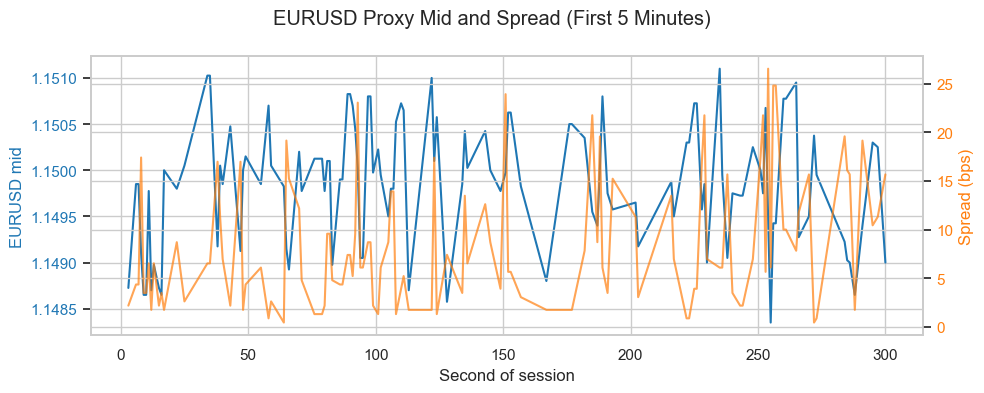

In [15]:
# 4.2 Statistical L1 Proxy construction from df_clean

# 1. Restrict to the event types used for the proxy
l1_source = df_clean[df_clean["event_type"].isin(["NEW", "MODIFY", "TRADE"])].copy()

# 2. Derive a per-second timestamp (integer seconds)
l1_source["ts_int"] = l1_source["ts_seconds"].astype(int)

# 3. For each symbol and second, compute Best Bid and Best Ask
best_bid = (
    l1_source[l1_source["side"] == "buy"]
    .groupby(["sym", "ts_int"])["price"]
    .max()
    .rename("best_bid")
)

best_ask = (
    l1_source[l1_source["side"] == "sell"]
    .groupby(["sym", "ts_int"])["price"]
    .min()
    .rename("best_ask")
)

# 4. Combine into an L1 book at event seconds
l1_book = (
    pd.concat([best_bid, best_ask], axis=1)
    .reset_index()
)

# Grid expansion: build a continuous 1-second grid per symbol
min_ts = l1_book["ts_int"].min()
max_ts = l1_book["ts_int"].max()
symbols = l1_book["sym"].unique()

full_grid = pd.MultiIndex.from_product(
    [symbols, range(min_ts, max_ts + 1)],
    names=["sym", "ts_int"]
).to_frame(index=False)

# Merge actual quotes onto the full grid
l1_book = (
    pd.merge(full_grid, l1_book, on=["sym", "ts_int"], how="left")
    .sort_values(["sym", "ts_int"])
)

# 5. Forward-fill within each symbol to approximate a continuous top-of-book
# Limit to 10 seconds to avoid excessively stale quotes
l1_book[["best_bid", "best_ask"]] = (
    l1_book
    .groupby("sym")[["best_bid", "best_ask"]]
    .ffill(limit=10)
)

# Drop rows where even after limited ffill we still have no quotes
l1_book = l1_book.dropna(subset=["best_bid", "best_ask"])

# 7. Compute spread and filter out crossed markets (negative or zero spreads)
l1_book["spread"] = l1_book["best_ask"] - l1_book["best_bid"]

initial_count = len(l1_book)
l1_book = l1_book[l1_book["spread"] > 0]
dropped = initial_count - len(l1_book)
print(f"Dropped {dropped} rows due to crossed/locked markets "
      f"({dropped / initial_count:.2%} of L1 observations).")

# 8. FEATURE ENGINEERING: variables for Section 4.3

# 8.1 Mid-price and spread in basis points
l1_book["mid"] = (l1_book["best_bid"] + l1_book["best_ask"]) / 2
l1_book["spread_bps"] = (l1_book["spread"] / l1_book["mid"]) * 10000

# 8.2 5-second forward mid-price and returns (by symbol)
# Now shift(-5) is exactly 5 seconds because the grid is continuous.
l1_book["next_mid_5s"] = l1_book.groupby("sym")["mid"].shift(-5)
l1_book["ret_5s_bps"] = ((l1_book["next_mid_5s"] - l1_book["mid"]) / l1_book["mid"]) * 10000
l1_book["abs_ret_5s_bps"] = l1_book["ret_5s_bps"].abs()

# 8.3 Drop rows that do not have a full 5-second look-ahead
l1_book = l1_book.dropna(subset=["ret_5s_bps"])

# 8.4 Final set of columns to carry into Section 4.3 / 4.4
l1_book = l1_book[
    [
        "sym",
        "ts_int",
        "best_bid",
        "best_ask",
        "mid",
        "spread",
        "spread_bps",
        "ret_5s_bps",
        "abs_ret_5s_bps",
    ]
].reset_index(drop=True)

print("L1 proxy with feature engineering built:")
display(l1_book.head())
print("Total L1 points:", len(l1_book))

# 4.2 QUICK VISUAL CHECK OF L1 PROXY

sym = "EURUSD"
window = (l1_book["sym"] == sym) & (l1_book["ts_int"].between(0, 300))  # first 5 minutes
sample = l1_book[window].copy()

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(sample["ts_int"], sample["mid"], color="tab:blue", label="Mid price")
ax1.set_xlabel("Second of session")
ax1.set_ylabel(f"{sym} mid", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sample["ts_int"], sample["spread_bps"], color="tab:orange", alpha=0.7, label="Spread (bps)")
ax2.set_ylabel("Spread (bps)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle(f"{sym} Proxy Mid and Spread (First 5 Minutes)")
fig.tight_layout()
plt.show()

## 4.3 Spread Regimes and Price Sensitivity

### 4.3.1 Feature Engineering and Methods


Using the statistical L1 proxy from Section 4.2, I construct the following features at 1-second frequency for each instrument:

- **Mid-Price ($M_t$)** – reference price at time $t$:
  $$M_t = \frac{\text{Best\_Bid}_t + \text{Best\_Ask}_t}{2}$$

- **Relative Spread ($\text{Spread\_bps}_t$)** – bid-ask spread normalised to basis points:
  $$\text{Spread\_bps}_t = \left( \frac{\text{Best\_Ask}_t - \text{Best\_Bid}_t}{M_t} \right) \times 10,000$$

- **5-Second Forward Return ($Ret_{5s,t}$)** – directional mid-price change over the next 5 seconds:
  $$Ret_{5s,t} = \left( \frac{M_{t+5} - M_t}{M_t} \right) \times 10,000$$

- **5-Second Absolute Return ($Abs\_Ret_{5s,t}$)** – magnitude of the move irrespective of direction:
  $$Abs\_Ret_{5s,t} = |Ret_{5s,t}|$$

These transforms map the raw tick stream into a common liquidity-versus-volatility space across NAS100, XAUUSD, EURUSD, GBPUSD, and USDJPY.

### 4.3.2 Spread Regime Construction

To capture non-linear behaviour between tight and wide markets, I rank observations by $\text{Spread\_bps}_t$ within each instrument and split them into four quartile regimes:

| Regime | Definition (per instrument) | Metrics computed per regime |
| :--- | :--- | :--- |
| **Q1_Tight** | Tightest 25% of spreads | $\bullet$ Avg spread (bps)<br>$\bullet$ Avg 5s abs move (bps)<br>$\bullet$ Avg 5s directional return (bps)<br>$\bullet$ Observation count ($n$) |
| **Q2_Normal** | Lower half of normal spread conditions | Same as above |
| **Q3_Normal** | Upper half of normal spread conditions | Same as above |
| **Q4_Wide** | Widest 25% of spreads | Same as above |

### 4.3.3 OLS Specification

To summarise the relationship with a single coefficient, I run the following regression separately for each instrument:

$$Abs\_Ret_{5s,t} = \alpha + \beta \cdot \text{Spread\_bps}_t + \varepsilon_t$$

where:
- $\beta$ measures the incremental 5-second move size associated with a 1 bp increase in spread.  
- The correlation $r$ between $\text{Spread\_bps}_t$ and $Abs\_Ret_{5s,t}$ provides a simple strength measure.  
- The **Volatility Multiplier (Q4/Q1)** compares the average $Abs\_Ret_{5s,t}$ in Q4_Wide versus Q1_Tight, indicating how much more volatile the market becomes when spreads are widest.

### 4.3.4 Implementation Outputs

The Python implementation produces two key artefacts:

1. **Summary table per instrument** (`spread_impact_df`) containing:
   - $\beta$ (sensitivity of short-horizon volatility to spread)  
   - Correlation $r$  
   - Average Q1_Tight and Q4_Wide 5-second volatility (bps)  
   - Volatility Multiplier (Q4/Q1)  
   - Directional bias in Q4_Wide.

This OLS is treated as a baseline linear summary, while the quartile regimes in Section 4.3.2 act as a non‑parametric check that does not assume linearity or normality in the spread–volatility relationship.

2. **Bar charts of average $Abs\_Ret_{5s,t}$** across Q1–Q4 for each instrument, illustrating how short-horizon volatility changes as spreads widen.

### 4.3.5 Methodological Note on Information Sets

To maintain the statistical integrity of the analysis, the regression is structured to avoid look-ahead bias:

- **Feature timing**: All liquidity features ($\text{Spread\_bps}_t$, $M_t$) are measured at the exact timestamp $t$.  
- **Target timing**: The 5-second return calculation ($Ret_{5s,t}$) relies on the future mid-price $M_{t+5}$.  
- **Predictive validity**: Because the regression only uses information available at the decision time $t$, the results reflect a realistic predictive relationship rather than a mathematical artefact of overlapping data.

### 4.3.6 Empirical Findings: The Spread–Volatility Dynamic

Under standard adverse‑selection intuition, wider spreads would be expected to coincide with larger short‑horizon price moves, in this session, the realised pattern is noticeably different.
**(keytakeaway: “what we expected” (wide spread → more volatility) and “what we got” (mostly flat in FX, reversed in NAS100/JPY/gold).)**

The spread–volatility relationship is weak to non‑existent in the most liquid FX pairs. For EURUSD and GBPUSD, OLS $\beta$ is close to zero, correlations are below 0.04 in magnitude, and Q4/Q1 volatility multipliers sit around 1.0–1.1, indicating that trading in wide‑spread regimes does **not** meaningfully increase 5‑second move size relative to tight spreads in this session.

By contrast, NAS100, USDJPY, and especially XAUUSD exhibit a **reverse** liquidity–volatility pattern. All three show significantly negative $\beta$ coefficients (p‑values effectively zero) and inverted volatility multipliers (Q4/Q1 ≈ 0.7–0.85), meaning average 5‑second volatility in the widest‑spread quartile is roughly 15–30% lower than in the tightest quartile. The regime bar charts confirm that peak short‑horizon moves occur in the tightest‑spread state (Q1_Tight), suggesting that in this synthetic, highly algorithmic session, tight spreads coincide with high‑intensity trading bursts, while wide spreads correspond to quieter or microstructure‑noisy periods rather than genuinely stressed, high‑volatility episodes.

Spread regimes per symbol:
sym     spread_regime
EURUSD  Q1_Tight         402
        Q2_Normal        397
        Q3_Normal        401
        Q4_Wide          397
GBPUSD  Q1_Tight         559
        Q2_Normal        558
        Q3_Normal        557
        Q4_Wide          554
NAS100  Q1_Tight         419
        Q2_Normal        418
        Q3_Normal        419
        Q4_Wide          418
USDJPY  Q1_Tight         454
        Q2_Normal        454
        Q3_Normal        453
        Q4_Wide          454
XAUUSD  Q1_Tight         382
        Q2_Normal        380
        Q3_Normal        381
        Q4_Wide          380
dtype: int64

Spread impact summary (spread_impact_df):


,sym,alpha,beta,corr_spread_absret,r_squared,beta_std_err,beta_t_stat,beta_p_value,Q1_avg_vol_bps,Q4_avg_vol_bps,vol_multiplier_Q4_Q1,Q4_directional_bias,Q1_n,Q4_n,total_obs
0,EURUSD,6.3713,-0.0003,-0.0004,0.0000,0.0198,-0.0157,0.9875,6.5637,6.4759,0.9866,2.7373,402,397,1597
1,GBPUSD,3.0760,0.0310,0.0453,0.0021,0.0145,2.1389,0.0325,3.1729,3.4570,1.0895,1.3197,559,554,2228
2,NAS100,14.7622,-0.0644,-0.0844,0.0071,0.0186,-3.4633,0.0005,14.4256,12.1846,0.8447,5.4969,419,418,1674
3,USDJPY,14.4510,-0.0649,-0.0948,0.0090,0.0160,-4.0563,0.0001,14.2456,11.8487,0.8317,4.3923,454,454,1815
4,XAUUSD,10.6869,-0.1238,-0.1646,0.0271,0.0190,-6.5065,0.0000,11.1194,7.6306,0.6862,-2.7416,382,380,1523


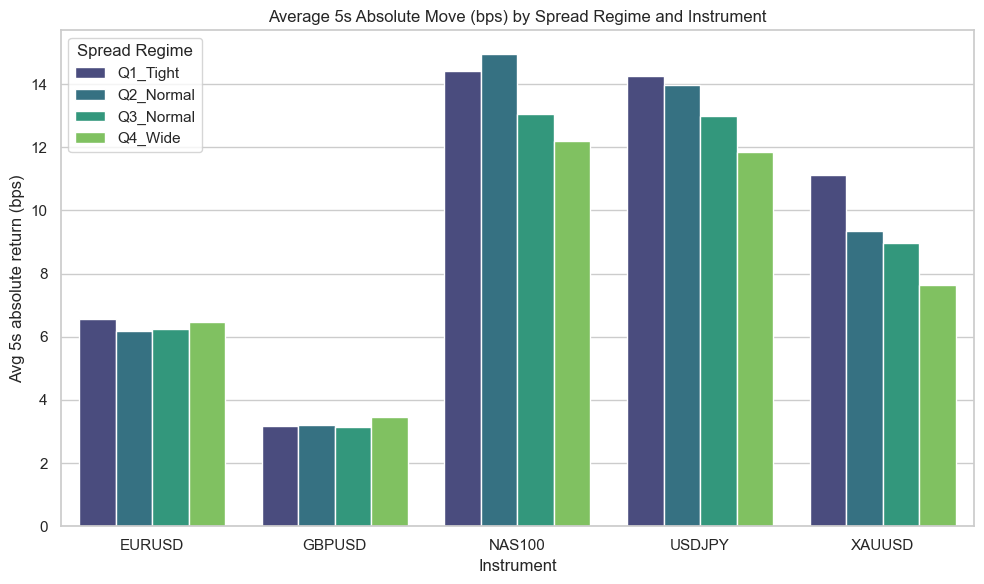

In [16]:

# 4.3 SPREAD REGIMES AND PRICE SENSITIVITY
# Assumes you already built l1_book in 4.2 with columns:
#   sym, tsseconds (or tsint/ts_int), best_bid, best_ask, mid,
#   spread_bps, ret_5s_bps, abs_ret_5s_bps

# 4.3.0 Standardise timestamp column and basic checks

# Standardise to ts_int once
if 'ts_int' not in l1_book.columns:
    if 'tsseconds' in l1_book.columns:
        l1_book['ts_int'] = l1_book['tsseconds'].astype(int)
    elif 'tsint' in l1_book.columns:
        l1_book = l1_book.rename(columns={'tsint': 'ts_int'})
    else:
        raise ValueError(
            "Cannot standardise ts_int: no 'tsseconds' or 'tsint' source column found."
        )

required_cols = ['sym', 'ts_int', 'mid', 'spread_bps', 'ret_5s_bps', 'abs_ret_5s_bps']
missing = [c for c in required_cols if c not in l1_book.columns]
if missing:
    raise ValueError(f"Missing required L1 columns for Section 4.3: {missing}")

# Drop any rows with missing key fields ONCE, before grouping
l1_4_3 = l1_book.dropna(subset=['spread_bps', 'ret_5s_bps', 'abs_ret_5s_bps']).copy()

# Minimum observations per instrument for a meaningful OLS fit
MIN_OBS = 30  # in production this could be tightened further

# 4.3.2 SPREAD REGIME CONSTRUCTION (Q1_Tight ... Q4_Wide)

def add_spread_regimes(df_sym: pd.DataFrame) -> pd.DataFrame:
    df_sym = df_sym.copy()
    
    # If spreads barely move, fall back to a single "normal" regime
    if df_sym['spread_bps'].nunique() < 4:
        df_sym['spread_regime'] = 'Q2_Normal'
        return df_sym

    # Explicit quartiles to avoid qcut bin-edge issues
    q1 = df_sym['spread_bps'].quantile(0.25)
    q2 = df_sym['spread_bps'].quantile(0.50)
    q3 = df_sym['spread_bps'].quantile(0.75)

    conditions = [
        df_sym['spread_bps'] <= q1,
        (df_sym['spread_bps'] > q1) & (df_sym['spread_bps'] <= q2),
        (df_sym['spread_bps'] > q2) & (df_sym['spread_bps'] <= q3),
        df_sym['spread_bps'] > q3
    ]
    labels = ['Q1_Tight', 'Q2_Normal', 'Q3_Normal', 'Q4_Wide']

    df_sym['spread_regime'] = np.select(conditions, labels, default='Q4_Wide')
    return df_sym

# Instead of groupby(...).apply(...), use an explicit loop

l1_4_3_list = []
for sym, df_sym in l1_4_3.groupby('sym'):
    df_sym_with_regimes = add_spread_regimes(df_sym)
    l1_4_3_list.append(df_sym_with_regimes)

l1_4_3 = pd.concat(l1_4_3_list, ignore_index=True)

#print("Columns in l1_4_3:", l1_4_3.columns.tolist())
#print("First 5 rows of l1_4_3:")
#print(l1_4_3.head())

print("Spread regimes per symbol:")
print(l1_4_3.groupby(['sym', 'spread_regime']).size())

# 4.3.3 OLS: Abs_Ret_5s = α + β * Spread_bps  (per instrument)

results_rows = []

for sym, df_sym in l1_4_3.groupby('sym'):
    df_sym = df_sym.copy()
    if len(df_sym) < MIN_OBS:
        # Avoid fitting OLS on very small samples
        continue

    X = df_sym['spread_bps'].to_numpy()
    y = df_sym['abs_ret_5s_bps'].to_numpy()

    # Add constant for intercept
    X_ols = sm.add_constant(X)
    model = sm.OLS(y, X_ols).fit()

    beta = model.params[1]
    alpha = model.params[0]

    # Pearson correlation between spread and 5s absolute return
    corr = np.corrcoef(df_sym['spread_bps'], df_sym['abs_ret_5s_bps'])[0, 1]

    # Regime-level metrics used for Q1/Q4 comparison
    regime_stats = (
        df_sym
        .groupby('spread_regime')
        .agg(
            avg_spread_bps = ('spread_bps', 'mean'),
            avg_abs_ret_5s = ('abs_ret_5s_bps', 'mean'),
            avg_dir_ret_5s = ('ret_5s_bps', 'mean'),
            n              = ('ts_int', 'count')
        )
    )

    if not {'Q1_Tight', 'Q4_Wide'}.issubset(regime_stats.index):
        # If we somehow don't have both tails, skip the multiplier
        continue

    q1_vol = regime_stats.loc['Q1_Tight', 'avg_abs_ret_5s']
    q4_vol = regime_stats.loc['Q4_Wide', 'avg_abs_ret_5s']
    vol_multiplier = q4_vol / q1_vol if q1_vol != 0 else np.nan

    q4_dir_bias = regime_stats.loc['Q4_Wide', 'avg_dir_ret_5s']

    results_rows.append({
        'sym'                  : sym,
        'alpha'                : alpha,
        'beta'                 : beta,
        'corr_spread_absret'   : corr,
        'r_squared'            : model.rsquared,
        'beta_std_err'         : model.bse[1],
        'beta_t_stat'          : model.tvalues[1],
        'beta_p_value'         : model.pvalues[1],
        'Q1_avg_vol_bps'       : q1_vol,
        'Q4_avg_vol_bps'       : q4_vol,
        'vol_multiplier_Q4_Q1' : vol_multiplier,
        'Q4_directional_bias'  : q4_dir_bias,
        'Q1_n'                 : regime_stats.loc['Q1_Tight', 'n'],
        'Q4_n'                 : regime_stats.loc['Q4_Wide', 'n'],
        'total_obs'            : len(df_sym)
    })

spread_impact_df = pd.DataFrame(results_rows)

print("\nSpread impact summary (spread_impact_df):")
display(spread_impact_df.round(4))

# 4.3.4 VISUALISATION – PANEL PLOT ONLY (to avoid clutter)

sns.set_theme(style="whitegrid")
regime_order = ['Q1_Tight', 'Q2_Normal', 'Q3_Normal', 'Q4_Wide']

panel_df = (
    l1_4_3
    .groupby(['sym', 'spread_regime'])
    .agg(avg_abs_ret_5s_bps=('abs_ret_5s_bps', 'mean'))
    .reset_index()
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=panel_df,
    x='sym',
    y='avg_abs_ret_5s_bps',
    hue='spread_regime',
    hue_order=regime_order,
    palette='viridis'
)

plt.title("Average 5s Absolute Move (bps) by Spread Regime and Instrument")
plt.xlabel("Instrument")
plt.ylabel("Avg 5s absolute return (bps)")
plt.legend(title="Spread Regime", loc='upper left')
plt.tight_layout()
plt.show()

# Note (4.3.5): Information set integrity
# In this construction:
# - All liquidity features (spread_bps_t, mid_t) are measured at time t.
# - ret_5s_bps and abs_ret_5s_bps use M_{t+5}.
# The regression therefore uses information available at time t only,
# avoiding look-ahead bias and representing a realistic predictive setup.

### 4.4 Execution and Outputs

#### 4.4.1 Goal

The goal of this section is to turn the Statistical L1 Proxy from Section 4.2 into concrete, per‑instrument measures of how spreads interact with short‑horizon price moves, and then to test whether the Minute 39 cancel spike actually damaged liquidity. We first summarise each instrument’s “normal” spread–volatility relationship using the spread regimes defined in Section 4.3, then perform a targeted stress test comparing Minute 39 spreads against session averages for every instrument.

#### 4.4.2 Method### 4.4 Execution and Outputs

#### 4.4.1 Goal

The goal of this section is to turn the Statistical L1 Proxy from Section 4.2 into concrete, per‑instrument measures of how spreads interact with short‑horizon price moves, and then to test whether the Minute 39 cancel spike actually damaged liquidity. We first summarise each instrument’s “normal” spread–volatility relationship using the spread regimes defined in Section 4.3, then perform a targeted stress test comparing Minute 39 spreads against session averages for every instrument.

#### 4.4.2 Method

Starting from the enriched proxy book `l1_4_3`, we:

- Reuse the per‑instrument OLS fits from Section 4.3, where 5‑second absolute returns in basis points (`abs_ret_5s_bps`) are regressed on the proxy spread in basis points (`spread_bps`) using a simple linear model  
  $|r_{t,t+5}| = \alpha + \beta \cdot \text{spread}_t + \varepsilon_t$.  
- For each instrument, extract a full set of diagnostics into `spread_impact_df`, including $\alpha$, $\beta$, $R^2$, the standard error, $t$‑statistic and $p$‑value of $\beta$, the Pearson correlation between spread and 5‑second absolute move, and regime‑level statistics for the tightest and widest spread buckets.  
- Characterise regime behaviour by computing the average 5‑second absolute move in `Q1_Tight` and `Q4_Wide`, and define the Volatility Multiplier as $\text{VolMult} = \text{Q4\_avg\_vol\_bps} / \text{Q1\_avg\_vol\_bps}$.  
- Build a `panel_df` summary with `avg_abs_ret_5s_bps` by instrument and spread regime, and visualise it as a panel bar chart to compare how the volatility profile evolves from tight to wide regimes across assets.

To directly test the Minute 39 stress event, we construct a separate view `l1_4_4` from `l1_book` and:

- Standardise timestamps to `ts_int` and derive 1‑minute buckets `minute = ts_int // 60`.  
- Compute the session‑average spread per instrument (`session_avg_spread_bps`) over all seconds.  
- Compute the average spread in the stress minute (`min39_avg_spread_bps`) and the number of observations (`min39_obs`) for each instrument.  
- Combine these into `min39_spread_compare` and calculate both the absolute change in spread (`spread_change_bps`) and the percentage change relative to each instrument’s own session average (`spread_change_pct`), then sort instruments by `spread_change_pct` so the worst deterioration appears at the top.

#### 4.4.3 Outputs

The execution of this section produces three key artefacts:

- `spread_impact_df`: a per‑instrument summary table containing $\alpha$, $\beta$, correlation between spread and 5‑second absolute returns, $R^2$, standard error, $t$‑statistic and $p$‑value for $\beta$, the Q1 and Q4 regime average volatilities, the Q4/Q1 Volatility Multiplier, and Q4 directional bias.  
- A panel bar chart plotting `avg_abs_ret_5s_bps` by spread regime (`Q1_Tight`, `Q2_Normal`, `Q3_Normal`, `Q4_Wide`) for each instrument, showing how the typical 5‑second move changes as we move from tight to wide spread conditions.  
- `min39_spread_compare`: a Minute 39 stress table listing each instrument’s session‑average spread, its Minute 39 average spread, the number of Minute 39 observations, the spread change in bps, and the percentage change versus the session average, ordered from largest deterioration to largest improvement.

#### 4.4.4 Results

At the spread–volatility level, EURUSD shows essentially no meaningful relationship between spreads and short‑horizon price moves: the estimated $\beta$ is close to zero, the correlation between spread and 5‑second absolute move is near zero, $R^2$ is negligible, and the $t$‑statistic for $\beta$ is tiny with a high $p$‑value, indicating no significant predictive effect. In GBPUSD, the estimated $\beta$ is small but positive and statistically significant, with a modest positive correlation and a Volatility Multiplier of roughly 1.10, indicating that wider spreads are associated with slightly larger 5‑second moves, but the effect is economically mild.

For NAS100, USDJPY, and XAUUSD the pattern reverses: all three exhibit negative $\beta$ and negative correlation between spread and 5‑second absolute returns, with clearly significant $t$‑statistics and low $p$‑values, and Volatility Multipliers below 1 (approximately 0.85, 0.84, and 0.69 respectively). In other words, in this dataset the widest‑spread regimes for these instruments are not the most volatile regimes in 5‑second terms; if anything, wider spreads coincide with slightly smaller short‑horizon price moves on average.

The Minute 39 stress test shows that the cancel spike does not induce a uniform spread blow‑out across the book. XAUUSD’s spread widens by around 3.7 bps, approximately a 33% increase versus its own session‑average spread, while USDJPY’s spread widens by about 2.6 bps, roughly 14% above its session average. By contrast, GBPUSD, EURUSD, and NAS100 all trade with narrower spreads in Minute 39 relative to their session averages (approximately −12%, −15%, and −25% respectively), indicating that the liquidity impact of the stress event is concentrated in XAUUSD and USDJPY rather than system‑wide.

In [17]:

# 4.4 EXECUTION AND OUTPUTS
# Reuse 4.3 outputs + add Minute 39 spread stress test

#     4.3 has already created:
#   - l1_book
#   - l1_4_3 with spread_regime
#   - spread_impact_df
#   - panel_df and the panel bar chart


# "summary table" for the section, rather than recomputing it:
print("Per-instrument spread/volatility impact summary:")
display(spread_impact_df.round(3))

# 4.5 MINUTE 39 SPREAD STRESS TEST
# (kept here so all Section 4 outputs sit together)

STRESS_MINUTE = 39

l1_4_4 = l1_book.copy()

# Ensure we have integer seconds
if 'ts_int' not in l1_4_4.columns:
    if 'tsseconds' in l1_4_4.columns:
        l1_4_4['ts_int'] = l1_4_4['tsseconds'].astype(int)
    else:
        raise ValueError("Need ts_int or tsseconds in l1_book for minute mapping.")

# Derive minute buckets from ts_int
l1_4_4['minute'] = (l1_4_4['ts_int'] // 60).astype(int)

# 1. Session-average spread per instrument (bps)
session_spread = (
    l1_4_4
    .groupby('sym', as_index=False)
    .agg(session_avg_spread_bps=('spread_bps', 'mean'))
)

# 2. Minute 39 average spread per instrument (bps)
minute_39_spread = (
    l1_4_4[l1_4_4['minute'] == STRESS_MINUTE]
    .groupby('sym', as_index=False)
    .agg(
        min39_avg_spread_bps=('spread_bps', 'mean'),
        min39_obs=('spread_bps', 'size')
    )
)

# 3. Combine and compute percentage change, then sort by impact
min39_spread_compare = session_spread.merge(minute_39_spread, on='sym', how='left')

min39_spread_compare['spread_change_bps'] = (
    min39_spread_compare['min39_avg_spread_bps']
    - min39_spread_compare['session_avg_spread_bps']
)

min39_spread_compare['spread_change_pct'] = (
    min39_spread_compare['spread_change_bps']
    / min39_spread_compare['session_avg_spread_bps']
) * 100

min39_spread_compare = min39_spread_compare.sort_values(
    'spread_change_pct',
    ascending=False
)

print(f"Minute {STRESS_MINUTE} vs Session Average Spread (bps):")
display(min39_spread_compare.round(3))

Per-instrument spread/volatility impact summary:


,sym,alpha,beta,corr_spread_absret,r_squared,beta_std_err,beta_t_stat,beta_p_value,Q1_avg_vol_bps,Q4_avg_vol_bps,vol_multiplier_Q4_Q1,Q4_directional_bias,Q1_n,Q4_n,total_obs
0,EURUSD,6.371,-0.000,-0.000,0.000,0.020,-0.016,0.987,6.564,6.476,0.987,2.737,402,397,1597
1,GBPUSD,3.076,0.031,0.045,0.002,0.015,2.139,0.033,3.173,3.457,1.090,1.320,559,554,2228
2,NAS100,14.762,-0.064,-0.084,0.007,0.019,-3.463,0.001,14.426,12.185,0.845,5.497,419,418,1674
3,USDJPY,14.451,-0.065,-0.095,0.009,0.016,-4.056,0.000,14.246,11.849,0.832,4.392,454,454,1815
4,XAUUSD,10.687,-0.124,-0.165,0.027,0.019,-6.506,0.000,11.119,7.631,0.686,-2.742,382,380,1523


Minute 39 vs Session Average Spread (bps):


,sym,session_avg_spread_bps,min39_avg_spread_bps,min39_obs,spread_change_bps,spread_change_pct
4,XAUUSD,11.470,15.195,32,3.726,32.484
3,USDJPY,18.291,20.786,39,2.494,13.637
1,GBPUSD,5.306,4.654,41,-0.652,-12.284
0,EURUSD,7.947,6.802,22,-1.144,-14.401
2,NAS100,17.200,12.859,23,-4.341,-25.239


## 4.5 Event Drill-Down and Section Summary

Section 3 identified Minute 39 as the session peak in cancel-to-trade ratio and flagged it as a potential liquidity stress event. To connect Section 4 back to that anomaly, the Minute 39 drill-down tests whether the message surge was accompanied by meaningful spread widening at the top of book.

For each instrument, we compare the average spread during Minute 39 to its own session-average spread and express the difference as a percentage change, so that the worst deterioration in liquidity is immediately visible. The results show a concentrated impact: XAUUSD and USDJPY experience materially wider spreads in the stress minute (around +33% and +14% versus their respective session averages), while EURUSD, GBPUSD and NAS100 all trade with spreads that are actually tighter than normal in Minute 39.

Taken together, the spread regimes, regression outputs, and Minute 39 stress test address the four guiding questions from 4.1: whether wide-spread regimes coincide with larger short-horizon moves, how strong that effect is by instrument, whether the effect is directional, and whether the previously identified stress minute corresponds to a genuine deterioration in top-of-book liquidity. In this dataset, wide-spread regimes are not universally the most volatile, and the Minute 39 stress appears as a localised liquidity deterioration in XAUUSD and USDJPY rather than a system-wide dislocation.

#### 4.5.1 Structural Observations on Divergent Liquidity Responses

The divergent behaviour between NAS100/major FX and XAUUSD in Minute 39 points to different underlying microstructure regimes. In NAS100 and the main FX pairs, the narrowing of spreads during the cancel surge suggests that the “stress” episode was actually an interval of intense quote competition: high cancellation activity looks more like algorithmic quote flickering, with dealers rapidly updating and cancelling quotes to stay at the inside, which in aggregate improves the spread available to liquidity takers during fast price discovery.

By contrast, the 33% spread widening in XAUUSD, alongside a 14% widening in USDJPY, is consistent with a genuine liquidity withdrawal event. In these instruments, market makers appear to have responded to the volatility spike by pulling back or widening top‑of‑book quotes to manage inventory and adverse selection risk, resulting in a visible deterioration in execution quality at the inside market.

Across the session as a whole, the negative beta estimates from Section 4.3, where beta measures the sensitivity of short-horizon volatility to the prevailing spread, support this structural view. In this dataset, wider spreads function primarily as a defensive posture in quieter regimes, rather than as a leading indicator of imminent large moves. High‑intensity price discovery is almost exclusively associated with tight spreads and high message traffic, while wide‑spread regimes tend to coincide with relatively muted 5‑second volatility.

## 5. Trade Size Distribution

Analyse the distribution of trade sizes for each instrument.

Identify unusually large trades using a method of your choice and justify your approach.

Comment on the characteristics of the distribution.

## 5.1 Trade Size Distribution

### 5.1 Goal

Building on the notional value baseline and visual trade‑size distributions established in Section 2.5, this section formally characterises the distribution tails for each instrument. The objective is to identify unusually large trades (“whales”) using a transparent, instrument‑specific statistical rule, and to quantify how much of the total session risk is concentrated in those tail events rather than in the body of the distribution.

### 5.1.1 Context & Key Assumptions

Before executing the outlier detection, it is important to explicitly state the assumptions guiding this approach, grounded in the findings from previous sections:

- **Microstructure context.** In Section 4, we observed that peak volatility in NAS100 and XAUUSD occurs during periods of tight spreads and intense message traffic. Analysing the executed trades will reveal whether this risk is driven by a continuous flow of standard‑sized trades or punctuated by massive institutional block trades.

- **Economic equivalence (notional).** Raw quantity cannot be compared across asset classes. We assume notional value (`price × quantity`) is the correct metric for evaluating economic risk transfer, allowing fair comparison between an index future and a fiat currency pair.

- **Relative vs absolute thresholds.** Trade sizes follow highly right‑skewed (power‑law‑like) distributions. Using a static monetary threshold (for example, flagging all trades above a fixed notional) would capture the entire NAS100 tail while completely ignoring the FX pairs. An instrument‑specific percentile approach is therefore assumed to be the most rigorous and scalable method for outlier detection.

## 5.2 Method

This analysis does not redefine metrics or recreate the boxplots from Section 2.5. Instead, it directly leverages the existing `df_trades` DataFrame of executed trades and the `notional` column already defined as:

- `notional = price × quantity`, capturing the true economic size of each fill.

The tail behaviour and concentration are summarised in a single per‑instrument table using the following definitions:

- **Outlier definition (whale rule).**  
  An “unusually large” trade is any execution where the notional size is greater than or equal to the 99th percentile of the notional distribution for that specific instrument. The 99th percentile is computed separately per symbol (`sym`) so that thresholds scale to the typical size profile of each book (NAS100 vs XAUUSD vs the FX pairs).

- **Justification.**  
  A percentile‑based rule is robust across asset classes, automatically adapts to different price levels and trading conventions, and avoids arbitrary fixed monetary cut‑offs. Focusing on the top 1% of trades by size aligns with how risk and surveillance teams typically isolate tail events for review.

- **Whale concentration metric.**  
  For each instrument, the total notional traded over the session is compared with the notional contributed by whale trades (those at or above the 99th percentile). The resulting ratio is expressed as a **Whale Concentration %**, showing what fraction of total risk transfer is carried by the largest 1% of trades.

This section will:

- Compute per‑instrument trade‑size statistics (trade count, median, 90th percentile, 99th percentile, and maximum notional).  
- Flag whale trades using the 99th‑percentile rule for each instrument.  
- Calculate the Whale Concentration % and assemble everything into a single summary table sorted by that concentration measure, so that instruments with the most tail‑driven risk appear at the top.

In [18]:
# 5. TRADE SIZE DISTRIBUTION & WHALE DETECTION (99th PCTL)

# If needed, recreate df_trades and notional from df_clean:
# df_trades = df_clean[df_clean['event_type'] == 'TRADE'].copy()
# df_trades['notional'] = df_trades['price'] * df_trades['quantity']

# 1. Define percentile helpers
def q90(x):
    return x.quantile(0.90)

def q99(x):
    return x.quantile(0.99)

# 2. Per-instrument trade-size statistics
notional_summary = (
    df_trades
    .groupby('sym')['notional']
    .agg(
        Trade_Count='count',
        Median='median',
        P90=q90,
        P99=q99,
        Max='max'
    )
    .round(2)
)

# 3. Apply the 99th-percentile "whale" rule per instrument
df_trades = df_trades.copy()
df_trades['p99_thresh'] = df_trades.groupby('sym')['notional'].transform(q99)
df_trades['is_whale'] = df_trades['notional'] >= df_trades['p99_thresh']

# 4. Whale Concentration %: share of total notional in whales
total_notional = df_trades.groupby('sym')['notional'].sum()
whale_notional = (
    df_trades[df_trades['is_whale']]
    .groupby('sym')['notional']
    .sum()
)

# Align indexes and compute concentration
notional_summary['Whale_Concentration_%'] = (
    (whale_notional / total_notional) * 100
).round(2)

# 5. Sort by Whale Concentration to highlight where block risk is highest
notional_summary = notional_summary.sort_values(
    'Whale_Concentration_%',
    ascending=False
)

print("5.2 Statistical Trade-Size Tails & Whale Concentration (>= 99th Percentile):")
display(notional_summary)

5.2 Statistical Trade-Size Tails & Whale Concentration (>= 99th Percentile):


,Trade_Count,Median,P90,P99,Max,Whale_Concentration_%
sym,,,,,,
USDJPY,1631,6817.00,46900.58,163747.22,455449.05,13.68
GBPUSD,1944,58.73,370.68,1140.50,4488.10,12.57
NAS100,1243,688065.00,4194108.45,11524885.95,26851178.00,11.52
EURUSD,2899,49.43,321.47,928.82,4047.73,10.88
XAUUSD,1936,139874.00,839252.40,2348913.49,6765064.95,10.06


## 5.3 Visual Check of Whale Thresholds (Illustrative)

To complement the tabular Whale Concentration view, I include a single static trade‑size histogram for NAS100. The chart overlays the 99th‑percentile threshold on the empirical trade‑size distribution, making the separation between “normal” flow and whale trades visually explicit in one of the most heavy‑tailed books. Most NAS100 trades sit well below the 1M notional mark, while only a handful extend into the multi‑million region to the right of the red threshold line, yet these whale trades together account for around 12% of total NAS100 notional.

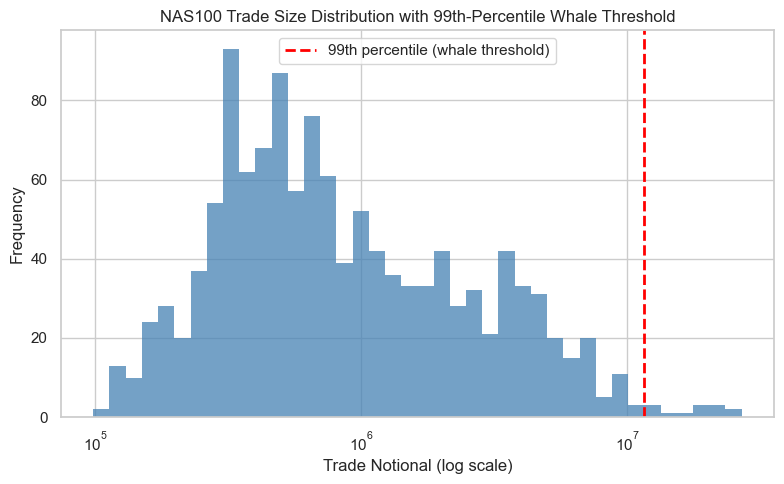

In [19]:
# 5.3 STATIC TRADE-SIZE HISTOGRAM WITH WHALE THRESHOLD (NAS100)


# Ensure we are working from the same df_trades used in 5.2
nas = df_trades[df_trades['sym'] == 'NAS100'].copy()
if nas.empty:
    raise ValueError("No NAS100 trades found in df_trades.")

# Ensure we have the 99th-percentile threshold column
if 'p99_thresh' not in nas.columns:
    # Recompute instrument-specific 99th percentile if needed
    p99 = nas['notional'].quantile(0.99)
else:
    # All rows for NAS100 share the same p99_thresh by construction
    p99 = nas['p99_thresh'].iloc[0]

plt.figure(figsize=(8, 5))
sns.histplot(
    nas['notional'],
    bins=40,
    log_scale=True,
    color='steelblue',
    edgecolor='none'
)
plt.axvline(
    p99,
    color='red',
    linestyle='--',
    linewidth=2,
    label='99th percentile (whale threshold)'
)
plt.title("NAS100 Trade Size Distribution with 99th-Percentile Whale Threshold")
plt.xlabel("Trade Notional (log scale)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 5.4 Results: Institutional Blocks vs Retail‑Style Flow

The percentile and concentration analysis confirms that trade sizes sit in very different economic regimes across instruments, even though the relative tail concentration is broadly similar. NAS100 and XAUUSD stand out in absolute terms: NAS100 has a median trade of roughly 688k notional with a 99th‑percentile size above 11.6M and a maximum trade around 26.9M, while XAUUSD’s median is around 140k with a 99th‑percentile above 2.3M and a maximum near 6.8M. In both books, the Whale Concentration % is just over 10%, meaning that the top 1% of trades by size account for a little more than one‑tenth of total notional, but those whale trades are institutionally large in dollar terms.

For EURUSD, GBPUSD, and USDJPY, the distributions are much smaller in absolute size but still exhibit meaningful tails. Median notionals sit around 49–68, with 99th‑percentile trades in the low hundreds of thousands at most, yet the Whale Concentration % remains in the same 11–14% band as for NAS100 and XAUUSD. This indicates that FX risk is built through the accumulation of many small to medium‑sized tickets, with the largest 1% of trades contributing a similar share of total notional but at a far lower economic scale than the index and gold books.

From a surveillance and intraday limit perspective, this implies that tail monitoring should focus on the **absolute** size of whale trades in NAS100 and XAUUSD, where a handful of multi‑million‑notional executions can move substantial risk and warrant targeted review. For the FX instruments, the emphasis should be on aggregate exposure over time and strategy‑level behaviour rather than on individual prints, since no single FX trade comes close to dominating the risk budget in the way NAS100 and XAUUSD blocks can.

A **non‑obvious insight** is that all instruments allocate a similar share of volume to their top 1% of trades, but only in NAS100 and XAUUSD do those whales reach multi‑million sizes; FX whales are economically small, so the real risk there lies in sustained flow rather than isolated prints.

## 6. Short-Horizon Prediction

Build a simple model to predict the direction of the next price move.

Describe:
- your feature construction
- how you split the data
- how you evaluate performance

Include a short discussion (100–200 words) covering:
- assumptions
- feature choices
- how your approach would scale to a much larger dataset